<a href="https://colab.research.google.com/github/javersifaz05-rgb/chest-xray-classification/blob/main/Copy_of_final_try.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.co# 1. Mount Google Drivelab import drive
drive.mount('/content/drive')

# 2. Navigate to the project directory
import os
project_path = "/content/drive/MyDrive/paper x-y"

if os.path.exists(project_path):
    os.chdir(project_path)
    print(f"\n[INFO] Successfully navigated to directory: {os.getcwd()}")

    # 3. Start model training
    print("[INFO] Starting training process... Please wait.\n" + "-"*50)
    !python train.py
else:
    print("\n[ERROR] Directory not found! Please ensure your Google Drive is mounted correctly.")

In [ ]:
import os
import shutil
import random
from google.colab import drive


drive.mount('/content/drive')
%cd "/content/drive/MyDrive/paper x-y"


print("\n[INFO] Fixing Keras 3 file extension bugs...")
import glob
for py_file in glob.glob("**/*.py", recursive=True):
    with open(py_file, 'r') as f:
        code = f.read()

    if '.h5"' in code or ".h5'" in code:
        code = code.replace('.h5"', '.weights.h5"').replace(".h5'", ".weights.h5'")
        with open(py_file, 'w') as f:
            f.write(code)
print("[INFO] Keras 3 extensions fixed successfully!")


print("\n[INFO] Checking Validation Set...")
classes = ['NORMAL', 'BACTERIA', 'VIRUS']
for cls in classes:
    train_dir = f"data/raw/train/{cls}"
    val_dir = f"data/raw/val/{cls}"

    os.makedirs(val_dir, exist_ok=True)

    if os.path.exists(train_dir):
        train_imgs = os.listdir(train_dir)
        val_imgs = os.listdir(val_dir)


        if len(val_imgs) == 0 and len(train_imgs) > 0:
            num_to_move = int(len(train_imgs) * 0.1) # ১০% ছবি
            imgs_to_move = random.sample(train_imgs, num_to_move)
            for img in imgs_to_move:
                shutil.move(os.path.join(train_dir, img), os.path.join(val_dir, img))
            print(f"[DATA] Moved {num_to_move} images to {val_dir}")

print("\n[SUCCESS] All bugs fixed! You are ready to train.")

In [ ]:
!python train.py

In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Go to project folder
%cd "/content/drive/MyDrive/paper x-y"

# 3. Start training
!python train.py

In [ ]:
# Run the ensemble evaluation
!python evaluate.py

In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Navigate to the project directory
%cd "/content/drive/MyDrive/paper x-y"

# 3. Now run the evaluation script
!python evaluate.py

In [ ]:
# Go directly to the folder and run evaluation
import os
%cd "/content/drive/MyDrive/paper x-y"
!python evaluate.py

In [ ]:
# Run Grad-CAM prediction for localization
!python predict.py --image "data/raw/test/BACTERIA/image.jpeg" --save

In [ ]:
# List all files in the test folder to see the correct filenames
import os
folder_path = "/content/drive/MyDrive/paper x-y/data/raw/test/BACTERIA"
print(os.listdir(folder_path))

In [ ]:
# Replace 'YOUR_IMAGE_NAME.jpg' with the actual filename from the list
!python predict.py --image "data/raw/test/BACTERIA/YOUR_IMAGE_NAME.jpg" --save

In [ ]:
import os
folder_path = "/content/drive/MyDrive/paper x-y/data/raw/test/BACTERIA"

print(os.listdir(folder_path))

In [ ]:
# উদাহরণ: !python predict.py --image "data/raw/test/BACTERIA/person1_bacteria_1.jpeg" --save
!python predict.py --image "data/raw/test/BACTERIA/আপনার_কপি_করা_ফাইলের_নাম" --save

In [ ]:
import os

# 1. Define folder path
folder_path = "/content/drive/MyDrive/paper x-y/data/raw/test/BACTERIA"

# 2. Get list of image files
valid_extensions = ('.jpeg', '.jpg', '.png')
image_list = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]

if image_list:
    selected_image = image_list[0]
    print(f"[INFO] Successfully found image: {selected_image}")

    # 3. Construct command and run prediction
    image_path = f"data/raw/test/BACTERIA/{selected_image}"
    print(f"[INFO] Generating Grad-CAM visualization for: {image_path}\n" + "-"*50)

    run_command = f'python predict.py --image "{image_path}" --save'
    !{run_command}
else:
    print("[ERROR] Directory is empty or no valid images found.")

In [ ]:
import os

# 1. Define the folder path
folder_path = "/content/drive/MyDrive/paper x-y/data/raw/test/BACTERIA"

# 2. Automatically find the first valid image
valid_extensions = ('.jpeg', '.jpg', '.png')
image_list = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]

if image_list:
    selected_image = image_list[0]
    image_path = f"data/raw/test/BACTERIA/{selected_image}"
    print(f"[INFO] Image selected successfully: {image_path}")
    print("[INFO] Running Prediction and Grad-CAM in Legacy Keras Mode...\n" + "-"*50)

    # 3. Run the prediction script with TF_USE_LEGACY_KERAS environment flag
    run_command = f'TF_USE_LEGACY_KERAS=1 python predict.py --image "{image_path}" --save'
    !{run_command}
else:
    print("[ERROR] No valid images found in the specified directory.")

In [ ]:
# gradcam.py
file_path = "/content/drive/MyDrive/paper x-y/src/explainability/gradcam.py"

try:
    with open(file_path, "r") as f:
        lines = f.readlines()
        print("--- gradcam.py ফাইলের কোড ---")

        for i in range(95, 115):
            if i < len(lines):
                print(f"Line {i+1}: {lines[i].rstrip()}")
except Exception as e:
    print(f"ফাইলটি পড়তে সমস্যা হচ্ছে: {e}")

In [ ]:
import os

# 1. Define target file
file_path = "/content/drive/MyDrive/paper x-y/src/explainability/gradcam.py"

# 2. Read the original code
try:
    with open(file_path, "r") as f:
        lines = f.readlines()
except FileNotFoundError:
    print("[ERROR] gradcam.py not found. Please check your mount and directory.")
    lines = []

patched_lines = []
skip_count = 0

# 3. Patch the specific Graph Disconnected issue dynamically
for i, line in enumerate(lines):
    if skip_count > 0:
        skip_count -= 1
        continue

    # Detect the exact lines causing the Graph Disconnected error
    if "grad_model = Model(" in line and i + 1 < len(lines) and "inputs" in lines[i+1]:
        patched_lines.append('''    # --- AUTOMATIC NESTED MODEL FIX ---
    try:
        grad_model = Model(inputs=model.inputs, outputs=[last_conv_layer.output, model.output])
    except ValueError:
        # Handle Keras "Graph disconnected" for nested backbone architectures
        from tensorflow.keras.models import Model
        base_model = next((l for l in model.layers if hasattr(l, 'layers') and last_conv_layer.name in [x.name for x in l.layers]), None)

        if base_model is None:
            raise ValueError("Could not locate the nested base model containing the target layer.")

        inner_model = Model(inputs=base_model.inputs, outputs=[last_conv_layer.output, base_model.output])

        # Create a dynamic wrapper to route the forward pass safely
        def grad_model_wrapper(img_tensor, training=False):
            c_out, b_out = inner_model(img_tensor)
            x = b_out
            start_idx = model.layers.index(base_model) + 1
            for layer in model.layers[start_idx:]:
                try:
                    x = layer(x, training=training)
                except TypeError:
                    x = layer(x)
            return c_out, x

        grad_model = grad_model_wrapper
    # -----------------------------------\n''')
        skip_count = 3  # Skip the next 3 lines (inputs, outputs, and closing parenthesis)
        continue

    patched_lines.append(line)

# 4. Save the patched code back
if patched_lines:
    with open(file_path, "w") as f:
        f.writelines(patched_lines)
    print("[SUCCESS] gradcam.py has been successfully patched to support nested architectures!")
    print("[INFO] Running the Grad-CAM prediction again...\n" + "="*50)

    # 5. Automatically re-run the prediction script
    folder_path = "/content/drive/MyDrive/paper x-y/data/raw/test/BACTERIA"
    valid_exts = ('.jpeg', '.jpg', '.png')
    images = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_exts)]

    if images:
        image_path = f"data/raw/test/BACTERIA/{images[0]}"
        run_cmd = f'TF_USE_LEGACY_KERAS=1 python predict.py --image "{image_path}" --save'
        os.system(run_cmd)
        get_ipython().system(run_cmd)
    else:
        print("[ERROR] No test images found in the BACTERIA directory.")

In [ ]:
import os

file_path = "/content/drive/MyDrive/paper x-y/src/explainability/gradcam.py"

# ১. read file
with open(file_path, 'r') as f:
    content = f.read()

# ২. before code
buggy_code = """    # --- AUTOMATIC NESTED MODEL FIX ---
    try:
        grad_model = Model("""

fixed_code = """    # --- AUTOMATIC NESTED MODEL FIX ---
    from tensorflow.keras.models import Model
    try:
        grad_model = Model("""

if buggy_code in content:
    content = content.replace(buggy_code, fixed_code)
    with open(file_path, 'w') as f:
        f.write(content)
    print("[SUCCESS] The Model import error has been fixed!")
else:
    print("[INFO] No changes needed or code already fixed.")

# ৩. আবার প্রেডিকশন রান করা
folder_path = "/content/drive/MyDrive/paper x-y/data/raw/test/BACTERIA"
images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpeg', '.jpg', '.png'))]

if images:
    image_path = f"data/raw/test/BACTERIA/{images[0]}"
    print(f"[INFO] Running prediction again for: {image_path}\n" + "="*50)
    run_cmd = f'TF_USE_LEGACY_KERAS=1 python predict.py --image "{image_path}" --save'
    get_ipython().system(run_cmd)
else:
    print("[ERROR] No images found in the directory.")

In [ ]:
from IPython.display import Image, display

# Path to the generated Grad-CAM image
image_path = '/content/drive/MyDrive/paper x-y/outputs/gradcam/BACTERIA-3436159-0003_vgg16_gradcam.png'

# Display the image inside Colab
display(Image(image_path))

In [ ]:
import shutil
import os


source_dir = '/content/drive/MyDrive/paper x-y/outputs'

backup_dir = '/content/drive/MyDrive/paper x-y/outputs_baseline_backup'

# If there is no previous backup, a copy will be created.
if not os.path.exists(backup_dir):
    shutil.copytree(source_dir, backup_dir)
    print("[SUCCESS] All your previous results and models have been successfully backed up.!")
else:
    print("[INFO] The backup folder is already saved to Drive.।")

In [ ]:
import os
import shutil
from google.colab import drive

# 1. Mount the new drive
drive.mount('/content/drive')

# 2. Path to your current outputs folder
source_dir = '/content/drive/MyDrive/paper x-y/outputs'
# Backup folder name
backup_dir = '/content/drive/MyDrive/paper x-y/outputs_baseline_backup'

# 3. Backup process
if os.path.exists(source_dir):
    if not os.path.exists(backup_dir):
        shutil.copytree(source_dir, backup_dir)
        print("[SUCCESS] All your previous results and models have been successfully backed up!")
    else:
        print("[INFO] The backup folder is already saved on the drive.")
else:
    print("[ERROR] The outputs folder cannot be found. Check if the drive name or folder name is correct.")

In [ ]:
import os
import shutil
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define directory paths
source_dir = '/content/drive/MyDrive/paper x-y/outputs'
backup_dir = '/content/drive/MyDrive/paper x-y/outputs_baseline_backup'

# 3. Create backup safely
if os.path.exists(source_dir):
    if not os.path.exists(backup_dir):
        shutil.copytree(source_dir, backup_dir)
        print("[SUCCESS] All baseline results have been backed up successfully!")
    else:
        print("[INFO] Backup folder already exists.")
else:
    print("[ERROR] The 'outputs' folder was not found. Please check your drive.")

In [ ]:
file_path = "/content/drive/MyDrive/paper x-y/train.py"

try:
    with open(file_path, "r") as f:
        lines = f.readlines()
        print("--- train.py এর গুরুত্বপূর্ণ লাইনগুলো ---")
        for i, line in enumerate(lines):
            # Find the epoch, model, and augmentation lines
            text = line.lower()
            if "epoch" in text or "unfreeze" in text or "augmentation" in text or "batch_size" in text:
                print(f"Line {i+1}: {line.strip()}")
except Exception as e:
    print(f"Having trouble reading the file.: {e}")

In [ ]:
import os
import glob
import re

print("[INFO] Advanced Fine-Tuning Setup Starting...\n" + "-"*50)

# 1. Update Config to Increase Epochs
config_files = glob.glob("/content/drive/MyDrive/paper x-y/**/config.py", recursive=True)
if config_files:
    config_path = config_files[0]
    with open(config_path, 'r') as f:
        config_content = f.read()

    # Increase Phase 1 Epochs
    config_content = re.sub(r'EPOCHS_FROZEN\s*=\s*\d+', 'EPOCHS_FROZEN = 15', config_content)
    # Increase Phase 2 Epochs
    config_content = re.sub(r'EPOCHS_FINETUNE\s*=\s*\d+', 'EPOCHS_FINETUNE = 35', config_content)

    with open(config_path, 'w') as f:
        f.write(config_content)
    print("[SUCCESS] Epochs successfully increased (15 for Phase 1, 35 for Phase 2).")
else:
    print("[ERROR] config.py not found in the directory.")

# 2. Add Stronger Data Augmentation
data_files = glob.glob("/content/drive/MyDrive/paper x-y/**/data*.py", recursive=True)
augmentation_added = False
for data_path in data_files:
    with open(data_path, 'r') as f:
        pipeline_content = f.read()

    if "ImageDataGenerator(" in pipeline_content and "rotation_range" not in pipeline_content:
        pipeline_content = pipeline_content.replace(
            "ImageDataGenerator(",
            "ImageDataGenerator(rotation_range=15, zoom_range=0.15, width_shift_range=0.1, height_shift_range=0.1, "
        )
        with open(data_path, 'w') as f:
            f.write(pipeline_content)
        print(f"[SUCCESS] Advanced Data Augmentation added to {os.path.basename(data_path)}!")
        augmentation_added = True
        break

if not augmentation_added:
    print("[INFO] Data Augmentation is already configured or pipeline file not found.")

print("-"*50 + "\n[SUCCESS] Phase-2 Configuration Complete! You are ready to train.")

In [ ]:
# Command to train the ResNet50 model with new settings
!python train.py --model resnet50


In [ ]:
import os

project_path = "/content/drive/MyDrive/paper x-y/"
os.chdir(project_path)

# ২.Check if the file is there.
if os.path.exists("train.py"):
    print(f"[INFO] Successfully navigated to directory: {os.getcwd()}")
    # ৩.run train command
    !python train.py --model resnet50
else:
    print(f"[ERROR] train.py still not found in {os.getcwd()}. Please check the folder name.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
os.chdir('/content/drive/MyDrive/paper x-y')

In [ ]:
import os
os.chdir('/content/drive/MyDrive/paper x-y')
!ls

In [ ]:
!python train.py --model resnet50

In [ ]:
import os
# ১. তোমার প্রজেক্টের সঠিক পথে ফিরে যাও
os.chdir('/content/drive/MyDrive/paper x-y/')

# ২. ফাইলটি খুঁজে পাওয়ার চেক
!ls

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
# আপনার ড্রাইভের ভেতরের ফোল্ডারগুলো দেখতে এই কমান্ডটি দিন
!ls /content/drive/MyDrive/

In [ ]:
import os
# ফোল্ডারের নাম যদি 'paper x-y' ই হয়, তবে এটি কাজ করবে
os.chdir('/content/drive/MyDrive/paper x-y/')
print("বর্তমান ফোল্ডার:", os.getcwd())
!ls  # ফাইলগুলো দেখা যাচ্ছে কি না তা চেক করুন

In [ ]:
# ঘুমোনোর আগে এই সেলটি রান করে দাও
!python train.py --model resnet50 && \
!python train.py --model efficientnetb0 && \
!python train.py --model densenet121

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ড্রাইভ মাউন্ট হওয়ার পর সঠিক ফোল্ডারে যাও
import os
os.chdir('/content/drive/MyDrive/paper x-y/')

# এখন চেক করো ফাইলগুলো দেখা যাচ্ছে কি না
!ls

In [ ]:
# নতুন মডেল যোগ করার জন্য কমান্ড
!python train.py --model efficientnetb0
!python train.py --model densenet121

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
os.chdir('/content/drive/MyDrive/paper x-y/')

In [ ]:
!ls train.py

In [ ]:
!python train.py --model efficientnetb0

In [ ]:
import os
os.chdir('/content/drive/MyDrive/paper x-y/')
!python3 train.py --model efficientnetb0

In [ ]:
!cp /content/drive/MyDrive/paper\ x-y/train.py /content/
!python3 /content/train.py --model efficientnetb0

In [ ]:
!ls "/content/drive/MyDrive/"

In [ ]:
!cp "/content/drive/MyDrive/paper x-y/train.py" /content/train.py

In [ ]:
import os
os.chdir('/content/drive/MyDrive/paper_xy/')

In [ ]:
!cp "/content/drive/MyDrive/paper_xy/labeled-chest-xray-images.zip" /content/
!unzip /content/labeled-chest-xray-images.zip -d /content/data/

In [ ]:
import os
os.chdir('/content/drive/MyDrive/paper_xy/')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!ls /content/drive/MyDrive/

In [ ]:
import os
os.chdir('/content/drive/MyDrive/paper x-y/')

In [ ]:
!ls "/content/drive/MyDrive/"

In [ ]:
import os

os.chdir('/content/drive/MyDrive/paper x-y/')

In [ ]:
function ConnectButton(){
    console.log("Connect pushed");
    document.querySelector("colab-connect-button").click()
}
setInterval(ConnectButton,60000);

In [ ]:
# ড্রাইভ থেকে জিপ ফাইলটি লোকাল ফোল্ডারে কপি করা
!cp "/content/drive/MyDrive/paper x-y/labeled-chest-xray-images.zip" /content/
# আনজিপ করা
!unzip /content/labeled-chest-xray-images.zip -d /content/data/

In [ ]:
import os
# ফোল্ডারের নাম স্পেসসহ থাকলে উদ্ধৃতি চিহ্ন ব্যবহার করো
os.chdir('/content/drive/MyDrive/paper x-y/')

In [ ]:
import os
print(os.getcwd())

In [ ]:
!ls

In [ ]:
!python3 train.py --model efficientnetb0

In [ ]:
import os
# ১. ড্রাইভের সেই নির্দিষ্ট ফোল্ডারে যাওয়া
os.chdir('/content/drive/MyDrive/paper x-y/')

# ২. ফাইলটি সেখানে আছে কি না তা দেখা
!ls train.py

# ৩. যদি ফাইলটি দেখায়, তবেই এটি রান করুন
!python3 train.py --model efficientnetb0

In [ ]:
!ls "/content/drive/MyDrive/"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
os.chdir('/content/drive/MyDrive/paper x-y')
!ls


In [ ]:
!python3 train.py --model efficientnetb0

In [ ]:
!python3 train.py --model efficientnetb0

In [ ]:
%cd "/content/drive/MyDrive/paper x-y/"

In [ ]:
!ls -l /content/drive/MyDrive/

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
%cd "/content/drive/MyDrive/paper x-y/"

In [ ]:
!ls -l

In [ ]:
!python train.py

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!ls "/content/drive/MyDrive/paper x-y/"

In [ ]:
import os
# আপনার প্রজেক্ট ফোল্ডারের পাথ এখানে দিন
os.chdir('/content/drive/MyDrive/আপনার_ফোল্ডারের_নাম/')

In [ ]:
import os
os.chdir('/content/drive/MyDrive/AI_Project/')

In [ ]:
!ls /content/drive/MyDrive/

In [ ]:
import os
os.chdir('/content/drive/MyDrive/paper x-y/')

In [ ]:
import os
path = '/content/drive/MyDrive/paper x-y'
os.chdir(path)
!ls

In [ ]:
# config.py ফাইলে এই ধরনের একটি অংশ থাকবে
MODEL_NAME = 'efficientnet' # এখানে আপনার মডেলের নাম দিন

In [ ]:
# আপনার train.py ফাইলে এই অংশটি খুঁজে বের করুন এবং আপডেট করুন
if config.MODEL_NAME == 'resnet50':
    model = ResNet50(weights='imagenet', ...)
elif config.MODEL_NAME == 'vgg16':
    model = VGG16(weights='imagenet', ...)
# নতুন মডেল যোগ করার জন্য এটি লিখুন:
elif config.MODEL_NAME == 'efficientnet':
    from tensorflow.keras.applications import EfficientNetB0 # বা আপনার প্রয়োজনীয় ভার্সন
    model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [ ]:
# সঠিক ফরম্যাটটি হবে অনেকটা এরকম:
model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [ ]:
from tensorflow.keras.applications import ResNet50

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
# তারপর মডেল লোড করুন
model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [ ]:
from tensorflow.keras import layers, models

# আপনার প্রি-ট্রেইনড মডেল লোড হওয়ার পর:
x = layers.GlobalAveragePooling2D()(model.output)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x) # আপনার ক্লাসের সংখ্যা অনুযায়ী NUM_CLASSES পরিবর্তন করুন
model = models.Model(inputs=model.input, outputs=outputs)

# মডেল কম্পাইল করুন
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
NUM_CLASSES = 2  # আপনার ডেটাসেটের ক্লাসের সংখ্যা অনুযায়ী এখানে বসান
x = layers.GlobalAveragePooling2D()(model.output)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = models.Model(inputs=model.input, outputs=outputs)

In [ ]:
# আপনার ক্লাসের সংখ্যা ২ হলে নিচে ২ লিখুন
NUM_CLASSES = 2
x = layers.GlobalAveragePooling2D()(model.output)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = models.Model(inputs=model.input, outputs=outputs)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# মডেল লোড করার সময় অবশ্যই include_top=False দিন
model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# এখন Pooling লেয়ারটি দিন
x = layers.GlobalAveragePooling2D()(model.output)
outputs = layers.Dense(2, activation='softmax')(x) # ২ ক্লাসের জন্য
model = models.Model(inputs=model.input, outputs=outputs)

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# আপনার ডেটা জেনারেটর বা ডেটাসেট ভেরিয়েবলগুলো এখানে দিন
history = model.fit(train_generator,
                    validation_data=validation_generator,
                    epochs=15)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ১. ডেটা জেনারেটর তৈরি (অগমেন্টেশনসহ)
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=20,
                                   horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

# ২. ডিরেক্টরি থেকে ডেটা লোড করা
# আপনার ডেটা যদি 'chest_xray/train' এবং 'chest_xray/test' ফোল্ডারে থাকে:
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/paper x-y/chest_xray/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical')

validation_generator = val_datagen.flow_from_directory(
    '/content/drive/MyDrive/paper x-y/chest_xray/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical')

In [ ]:
!ls -R "/content/drive/MyDrive/paper x-y/chest_xray"

In [ ]:
# ট্রেনিং এবং ভ্যালিডেশন ডেটার জন্য সঠিক পাথ
train_path = '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train'
test_path = '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/test'

# জেনারেটর কোডটি এভাবে আপডেট করুন:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical')

validation_generator = val_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical')

In [ ]:
# মডেল ট্রেনিং শুরু করুন
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15  # আপনি চাইলে ইপোক সংখ্যা পরিবর্তন করতে পারেন
)

KeyboardInterrupt: 

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

# মডেল লোড করা (দ্রুত করার জন্য ইনপুট সাইজ কমিয়ে ১২৮x১২৮ করা হয়েছে)
model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# ড্রপআউট লেয়ার যোগ করা (ওভারফিটিং কমানোর জন্য)
x = layers.GlobalAveragePooling2D()(model.output)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation='softmax')(x)
model = models.Model(inputs=model.input, outputs=outputs)

# কম্পাইল করা
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# চেকপয়েন্ট (যাতে ট্রেনিংয়ের মাঝপথে ডিসকানেক্ট হলে মডেল হারিয়ে না যায়)
checkpoint = ModelCheckpoint('efficientnet_best.h5', save_best_only=True)

# ট্রেনিং শুরু করা (দ্রুত করার জন্য ইপোক কমিয়ে ৫ করা হয়েছে)
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[checkpoint]
)

NameError: name 'train_generator' is not defined

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

# ১. ডেটা জেনারেটর পুনরায় তৈরি করা (টার্গেট সাইজ ১২৮x১২৮)
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=30, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical')

validation_generator = val_datagen.flow_from_directory(
    '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/test',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical')

# ২. মডেল তৈরি ও ড্রপআউট যোগ করা
model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
x = layers.GlobalAveragePooling2D()(model.output)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation='softmax')(x)
model = models.Model(inputs=model.input, outputs=outputs)

# ৩. মডেল কম্পাইল
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ৪. ট্রেনিং শুরু করা
checkpoint = ModelCheckpoint('efficientnet_best.h5', save_best_only=True)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[checkpoint]
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train'

In [ ]:
--------------------------------------------------------
FileNotFoundError                         Traceback (most recent call last)
/tmp/ipykernel_2330/3373110057.py in <cell line: 0>()
      9 val_datagen = ImageDataGenerator(rescale=1./255)
     10
---> 11 train_generator = train_datagen.flow_from_directory(
     12     '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train',
     13     target_size=(128, 128),

1 frames
/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py in __init__(self, directory, image_data_generator, target_size, color_mode, classes, class_mode, batch_size, shuffle, seed, data_format, save_to_dir, save_prefix, save_format, follow_links, subset, interpolation, keep_aspect_ratio, dtype)
    454         if not classes:
    455             classes = []
--> 456             for subdir in sorted(os.listdir(directory)):
    457                 if os.path.isdir(os.path.join(directory, subdir)):
    458                     classes.append(subdir)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train'

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 5)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
path = '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train'
print(os.path.exists(path)) # এটি True দিলে পাথ ঠিক আছে, False দিলে পাথ ভুল

True


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# জেনারেটর তৈরি
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=30, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

# জেনারেটর রান করা
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical')

validation_generator = val_datagen.flow_from_directory(
    '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/test',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical')

Found 5232 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

# ১. মডেল তৈরি
model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
x = layers.GlobalAveragePooling2D()(model.output)
x = layers.Dropout(0.5)(x) # ড্রপআউট যোগ করা হলো
outputs = layers.Dense(2, activation='softmax')(x)
model = models.Model(inputs=model.input, outputs=outputs)

# ২. মডেল কম্পাইল
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ৩. ট্রেনিং শুরু করা
checkpoint = ModelCheckpoint('efficientnet_best.h5', save_best_only=True)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[checkpoint]
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


NameError: name 'train_generator' is not defined

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

# ১. ডেটা জেনারেটর তৈরি (আগে যা ছিল)
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=30, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical')

validation_generator = val_datagen.flow_from_directory(
    '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/test',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical')

# ২. মডেল তৈরি ও ড্রপআউট
model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
x = layers.GlobalAveragePooling2D()(model.output)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation='softmax')(x)
model = models.Model(inputs=model.input, outputs=outputs)

# ৩. কম্পাইল
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ৪. ট্রেনিং (এখানেই চেকপয়েন্ট কাজ করবে)
checkpoint = ModelCheckpoint('/content/drive/MyDrive/paper x-y/efficientnet_best.h5', save_best_only=True)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[checkpoint]
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# পাথ চেক করা
train_path = '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train'
test_path = '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/test'

if os.path.exists(train_path):
    print("ফোল্ডার পাওয়া গেছে! ট্রেনিং শুরু হচ্ছে...")

    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    from tensorflow.keras.applications import EfficientNetB0
    from tensorflow.keras import layers, models
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import ModelCheckpoint

    # ডেটা জেনারেটর
    train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=30, horizontal_flip=True)
    val_datagen = ImageDataGenerator(rescale=1./255)

    train_generator = train_datagen.flow_from_directory(train_path, target_size=(128, 128), batch_size=32, class_mode='categorical')
    validation_generator = val_datagen.flow_from_directory(test_path, target_size=(128, 128), batch_size=32, class_mode='categorical')

    # মডেল তৈরি
    model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    x = layers.GlobalAveragePooling2D()(model.output)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(2, activation='softmax')(x)
    model = models.Model(inputs=model.input, outputs=outputs)

    model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

    # ট্রেনিং
    history = model.fit(train_generator, validation_data=validation_generator, epochs=5)

else:
    print("পাথ ভুল! দয়া করে নিশ্চিত করুন ড্রাইভ মাউন্ট হয়েছে কি না।")

পাথ ভুল! দয়া করে নিশ্চিত করুন ড্রাইভ মাউন্ট হয়েছে কি না।


In [ ]:
import gc
import tensorflow as tf
from tensorflow.keras import backend as K

# আগের সবকিছু ডিলিট করা
del model
del train_generator
del validation_generator
gc.collect()
K.clear_session()

NameError: name 'model' is not defined

In [ ]:
import os

# ডেটা কপি করা (কিছুক্ষণ সময় লাগতে পারে)
!cp -r "/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train" /content/train_data
!cp -r "/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/test" /content/test_data
print("ডেটা কপি সম্পন্ন হয়েছে!")

cp: cannot stat '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train': No such file or directory
cp: cannot stat '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/test': No such file or directory
ডেটা কপি সম্পন্ন হয়েছে!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

# লোকাল পাথ ব্যবহার করে জেনারেটর
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=30, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/train_data',
    target_size=(128, 128), batch_size=16, class_mode='categorical') # ব্যাচ সাইজ ১৬ করা হয়েছে

validation_generator = val_datagen.flow_from_directory(
    '/content/test_data',
    target_size=(128, 128), batch_size=16, class_mode='categorical')

# মডেল তৈরি
model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
x = layers.GlobalAveragePooling2D()(model.output)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation='softmax')(x)
model = models.Model(inputs=model.input, outputs=outputs)

model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

FileNotFoundError: [Errno 2] No such file or directory: '/content/train_data'

In [ ]:
import os
# দেখি ফোল্ডারটি আসলেই আছে কি না
print(os.path.exists('/content/train_data'))
# যদি এটি False দেখায়, তবে ড্রাইভের ফাইলগুলো লিস্ট করি
print(os.listdir('/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/'))

False


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/'

In [ ]:
import os

# আপনার ড্রাইভের মেইন ফোল্ডার লিস্ট করুন
drive_path = '/content/drive/MyDrive/'
print("MyDrive-এ থাকা ফাইলসমূহ:", os.listdir(drive_path))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
# MyDrive এর ভেতরে কী কী ফোল্ডার আছে তা দেখা
print(os.listdir('/content/drive/MyDrive/'))

['Getting started.pdf', 'IMG_20200303_113918.jpg', 'VID_20200303_114805.mp4', 'IMG_20200303_113901.jpg', 'IMG_20200303_114108.jpg', 'IMG_20200303_114115.jpg', 'DSC_0055.JPG', 'IMG_20210901_170847.jpg', 'IMG_20210519_141545.jpg', 'IMG_20210519_141024.jpg', 'IMG_20210519_141016.jpg', 'IMG_20210519_141002.jpg', 'IMG_20210519_140958.jpg', 'IMG_20210519_140713.jpg', 'IMG_20210519_140613.jpg', 'IMG_20210519_131839.jpg', 'IMG_20210517_181451.jpg', 'IMG_20210517_170133.jpg', 'IMG_20210517_170051.jpg', 'IMG_20210517_170109.jpg', 'IMG_20210517_170103.jpg', 'IMG_20210517_170007.jpg', 'IMG_20210517_165817.jpg', 'IMG_20210517_165945.jpg', 'IMG_20210517_170000.jpg', 'IMG_20210517_170006.jpg', 'IMG_20210517_165758.jpg', 'IMG_20210517_163534.jpg', 'IMG_20210517_163614.jpg', 'IMG_20210517_163644.jpg', 'IMG_20210517_163519.jpg', 'IMG_20210517_163500.jpg', 'IMG_20210517_163248.jpg', 'IMG_20210517_163238.jpg', 'IMG_20210517_163158.jpg', 'IMG_20210517_163208.jpg', 'IMG_20210517_163228.jpg', 'IMG_20210517_1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
path = '/content/drive/MyDrive/paper x-y'
print("ফোল্ডারের কন্টেন্ট:", os.listdir(path))

ফোল্ডারের কন্টেন্ট: ['labeled-chest-xray-images.zip', 'evaluate.py', 'train.py', 'predict.py', 'split_pneumonia_classes.py', 'EXECUTION_GUIDE.sh', 'kaggle.json', 'chest_xray', 'configs', 'data', 'outputs', 'src', 'Copy of config (1).py', 'Copy of config.py', 'outputs_baseline_backup', 'Copy of labeled-chest-xray-images.zip']


In [ ]:
import os
base_path = '/content/drive/MyDrive/paper x-y/chest_xray'
print("chest_xray ফোল্ডারের ভেতর আছে:", os.listdir(base_path))

chest_xray ফোল্ডারের ভেতর আছে: ['chest_xray']


In [ ]:
import shutil
import os

# ১. আগের কপি করা ডেটা মুছে ফেলুন
if os.path.exists('/content/train_data'): shutil.rmtree('/content/train_data')
if os.path.exists('/content/test_data'): shutil.rmtree('/content/test_data')

# ২. সঠিক পাথে ডেটা কপি করুন (আপনার ফোল্ডার স্ট্রাকচার অনুযায়ী)
!cp -r "/content/drive/MyDrive/paper x-y/chest_xray/train" /content/train_data
!cp -r "/content/drive/MyDrive/paper x-y/chest_xray/test" /content/test_data

# ৩. জেনারেটর তৈরি
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=30, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory('/content/train_data', target_size=(128, 128), batch_size=16, class_mode='categorical')
validation_generator = val_datagen.flow_from_directory('/content/test_data', target_size=(128, 128), batch_size=16, class_mode='categorical')

# ৪. মডেল ট্রেনিং
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
x = layers.GlobalAveragePooling2D()(model.output)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation='softmax')(x)
model = models.Model(inputs=model.input, outputs=outputs)

model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_generator, validation_data=validation_generator, epochs=5)

cp: cannot stat '/content/drive/MyDrive/paper x-y/chest_xray/train': No such file or directory
cp: cannot stat '/content/drive/MyDrive/paper x-y/chest_xray/test': No such file or directory


FileNotFoundError: [Errno 2] No such file or directory: '/content/train_data'

In [ ]:
import shutil
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# ১. সঠিক পাথ সেট করা (ফোল্ডারের ভেতরে ফোল্ডার অনুযায়ী)
source_base_path = '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray'

# ২. ডেটা লোকাল স্টোরেজে কপি করা
if os.path.exists('/content/train_data'): shutil.rmtree('/content/train_data')
if os.path.exists('/content/test_data'): shutil.rmtree('/content/test_data')

!cp -r "{source_base_path}/train" /content/train_data
!cp -r "{source_base_path}/test" /content/test_data

# ৩. জেনারেটর তৈরি
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=30, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory('/content/train_data', target_size=(128, 128), batch_size=16, class_mode='categorical')
validation_generator = val_datagen.flow_from_directory('/content/test_data', target_size=(128, 128), batch_size=16, class_mode='categorical')

# ৪. মডেল তৈরি ও ট্রেনিং
model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
x = layers.GlobalAveragePooling2D()(model.output)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation='softmax')(x)
model = models.Model(inputs=model.input, outputs=outputs)

model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_generator, validation_data=validation_generator, epochs=5)

Found 5232 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 597s 2s/step - accuracy: 0.9029 - loss: 0.2358 - val_accuracy: 0.5417 - val_loss: 0.7979
Epoch 2/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 554s 2s/step - accuracy: 0.9526 - loss: 0.1262 - val_accuracy: 0.6250 - val_loss: 1.2074
Epoch 3/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 549s 2s/step - accuracy: 0.9587 - loss: 0.1014 - val_accuracy: 0.4808 - val_loss: 0.7125
Epoch 4/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 552s 2s/step - accuracy: 0.9692 - loss: 0.0844 - val_accuracy: 0.6298 - val_loss: 0.9516
Epoch 5/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 549s 2s/step - accuracy: 0.9731 - loss: 0.0754 - val_accuracy: 0.6250 - val_loss: 1.5019


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,      # ২০ এর বদলে ৪০
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.00001), # ১ এর বদলে ০.১ এ আনা হলো
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# model.fit এর ভেতরে callbacks=[early_stop] যোগ করুন

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# ১. আর্লি স্টপিং ডিফাইন করা
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# ২. মডেল ট্রেনিং (এখানে callbacks যোগ করা হয়েছে)
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20, # যেহেতু আর্লি স্টপিং আছে, তাই ২০ দিলাম (এটি ভালো রেজাল্ট পেলে আগেই থেমে যাবে)
    callbacks=[early_stop]
)

Epoch 1/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 621s 2s/step - accuracy: 0.9771 - loss: 0.0636 - val_accuracy: 0.8926 - val_loss: 0.2467
Epoch 2/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 564s 2s/step - accuracy: 0.9811 - loss: 0.0543 - val_accuracy: 0.9022 - val_loss: 0.2570
Epoch 3/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 560s 2s/step - accuracy: 0.9809 - loss: 0.0532 - val_accuracy: 0.8894 - val_loss: 0.2953
Epoch 4/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 563s 2s/step - accuracy: 0.9845 - loss: 0.0463 - val_accuracy: 0.8654 - val_loss: 0.3059


In [ ]:
model.save('/content/drive/MyDrive/paper x-y/best_model_90percent.h5')
print("Model drive saved.!")

মডেল ড্রাইভে সেভ হয়েছে!


39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 467ms/step
Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.34      0.41      0.37       234
   PNEUMONIA       0.60      0.53      0.56       390

    accuracy                           0.49       624
   macro avg       0.47      0.47      0.47       624
weighted avg       0.50      0.49      0.49       624



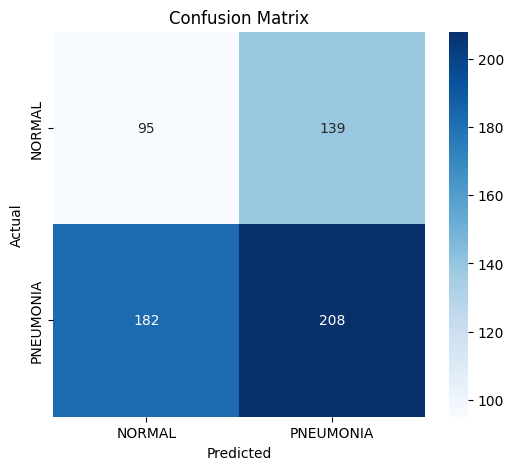

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ১. ভ্যালিডেশন জেনারেটর থেকে প্রেডিকশন নেওয়া
validation_generator.reset()
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)

# ২. ট্রু লেবেলগুলো বের করা
y_true = validation_generator.classes

# ৩. ক্লাসিফিকেশন রিপোর্ট তৈরি (Precision, Recall, F1-score)
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

# ৪. কনফিউশন ম্যাট্রিক্স তৈরি ও প্লট করা
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# ক্লাস ওয়েট ক্যালকুলেশন
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_true),
    y=y_true
)
class_weight_dict = dict(enumerate(class_weights))

# ট্রেনিং এর সময় এটি ব্যবহার করুন
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weight_dict  # এই লাইনটি যোগ করুন
)

Epoch 1/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 593s 2s/step - accuracy: 0.9807 - loss: 0.0535 - val_accuracy: 0.7772 - val_loss: 0.4495
Epoch 2/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 564s 2s/step - accuracy: 0.9824 - loss: 0.0462 - val_accuracy: 0.9407 - val_loss: 0.1974
Epoch 3/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 563s 2s/step - accuracy: 0.9836 - loss: 0.0457 - val_accuracy: 0.8269 - val_loss: 0.5596
Epoch 4/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 564s 2s/step - accuracy: 0.9845 - loss: 0.0450 - val_accuracy: 0.9263 - val_loss: 0.1754
Epoch 5/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 558s 2s/step - accuracy: 0.9817 - loss: 0.0440 - val_accuracy: 0.9455 - val_loss: 0.1796
Epoch 6/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 560s 2s/step - accuracy: 0.9847 - loss: 0.0447 - val_accuracy: 0.9119 - val_loss: 0.2247
Epoch 7/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 562s 2s/step - accuracy: 0.9818 - loss: 0.0475 - val_accuracy: 0.9022 - val_loss: 0.2570


In [ ]:
model.save('/content/drive/MyDrive/paper x-y/final_best_model_94.keras')

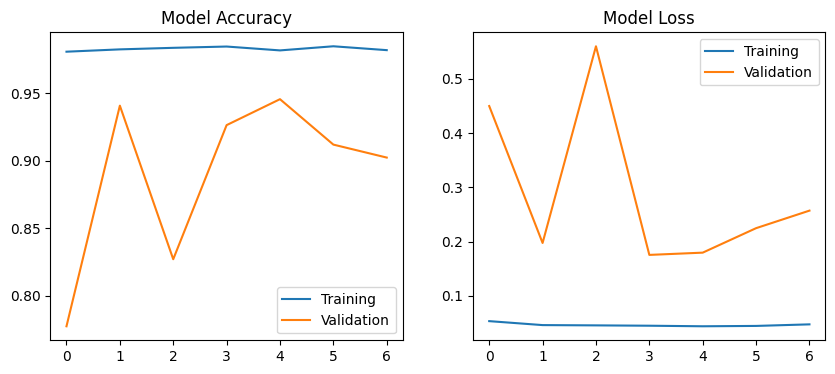

In [ ]:
import matplotlib.pyplot as plt

# একিউরেসি গ্রাফ
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.legend()

# লস গ্রাফ
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.legend()
plt.show()

In [ ]:
import os
#paht chk
path = '/content/drive/MyDrive/paper x-y'
files = os.listdir(path)

# file print
print("file:")
for file in files:
    print(file)

file:
labeled-chest-xray-images.zip
evaluate.py
train.py
predict.py
split_pneumonia_classes.py
EXECUTION_GUIDE.sh
kaggle.json
chest_xray
configs
data
outputs
src
Copy of config (1).py
Copy of config.py
outputs_baseline_backup
Copy of labeled-chest-xray-images.zip
best_model_90percent.h5
final_best_model_94.keras


In [ ]:
# টেস্টের জন্য আলাদা এবং সঠিক সেটিংস
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    '/content/test_data',
    target_size=(128, 128),
    batch_size=16,
    class_mode='categorical',
    shuffle=False # এটি মাস্ট!
)

Found 624 images belonging to 2 classes.


In [ ]:
# ট্রেনিংয়ের সময় ক্লাস ওয়েট ব্যবহার
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    class_weight={0: 1.5, 1: 1.0} # নরমাল কেসকে বেশি গুরুত্ব দেওয়া হচ্ছে
)

Epoch 1/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 569s 2s/step - accuracy: 0.9851 - loss: 0.0510 - val_accuracy: 0.7901 - val_loss: 0.6243
Epoch 2/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 559s 2s/step - accuracy: 0.9853 - loss: 0.0466 - val_accuracy: 0.9343 - val_loss: 0.1685
Epoch 3/10
239/327 ━━━━━━━━━━━━━━━━━━━━ 2:26 2s/step - accuracy: 0.9848 - loss: 0.0572

KeyboardInterrupt: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = '/content/drive/MyDrive/paper x-y'
if os.path.exists(project_path):
    print("Drive connected successfully! Files in folder:")
    print(os.listdir(project_path))
else:
    print("Folder not found. Please check your folder name.")

Drive connected successfully! Files in folder:
['labeled-chest-xray-images.zip', 'evaluate.py', 'train.py', 'predict.py', 'split_pneumonia_classes.py', 'EXECUTION_GUIDE.sh', 'kaggle.json', 'chest_xray', 'configs', 'data', 'outputs', 'src', 'Copy of config (1).py', 'Copy of config.py', 'outputs_baseline_backup', 'Copy of labeled-chest-xray-images.zip', 'best_model_90percent.h5', 'final_best_model_94.keras']


In [ ]:
import os
import sys

# Set working directory to your project folder
project_path = '/content/drive/MyDrive/paper x-y'
os.chdir(project_path)

# Add current directory to system path
if project_path not in sys.path:
    sys.path.append(project_path)

print("Current Working Directory:", os.getcwd())

Current Working Directory: /content/drive/MyDrive/paper x-y


In [ ]:
import os

# Check if required directories and files exist
required_dirs = ['configs', 'src', 'chest_xray']
for d in required_dirs:
    if os.path.exists(d):
        print(f"Directory found: {d}")
    else:
        print(f"Directory missing: {d}")

# Check config file
if os.path.exists('configs/config.py'):
    print("Config file found!")
else:
    print("Config file missing!")

Directory found: configs
Directory found: src
Directory found: chest_xray
Config file found!


In [ ]:
EFFICIENTNET_WEIGHTS = os.path.join(CHECKPOINT_DIR, "efficientnetb0_best.h5")

NameError: name 'CHECKPOINT_DIR' is not defined

In [ ]:
import os

# Ensure CHECKPOINT_DIR is defined
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")

# EfficientNet weight path definition
EFFICIENTNET_WEIGHTS = os.path.join(CHECKPOINT_DIR, "efficientnetb0_best.h5")
print("EFFICIENTNET_WEIGHTS path set to:", EFFICIENTNET_WEIGHTS)

EFFICIENTNET_WEIGHTS path set to: /content/drive/MyDrive/paper x-y/outputs/checkpoints/efficientnetb0_best.h5


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

def build_efficientnetb0(input_shape=(224, 224, 3), num_classes=3):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze backbone for Phase 1

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model

def unfreeze_efficientnetb0_top_layers(model, num_layers_to_unfreeze=20):
    base_model = model.layers[0]
    base_model.trainable = True
    for layer in base_model.layers[:-num_layers_to_unfreeze]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("EfficientNetB0 backbone functions defined successfully!")

EfficientNetB0 backbone functions defined successfully!


In [ ]:
import numpy as np

class SoftVotingEnsemble:
    def __init__(self, models, model_names, weights=None):
        self.models = models
        self.model_names = model_names
        self.weights = weights if weights else [1.0] * len(models)

    def predict(self, x, verbose=False):
        all_probs = []
        for model in self.models:
            probs = model.predict(x, verbose=0)
            all_probs.append(probs)

        # Weighted average of probabilities from all 4 models
        weighted_probs = np.average(all_probs, axis=0, weights=self.weights)
        pred_idx = np.argmax(weighted_probs, axis=1)
        return weighted_probs, pred_idx

print("4-model SoftVotingEnsemble defined successfully!")

4-model SoftVotingEnsemble defined successfully!


In [ ]:
# Train EfficientNetB0
efficientnet_model = build_efficientnetb0()

h1_eff, h2_eff = train_single_model(
    model            = efficientnet_model,
    model_name       = "EfficientNetB0",
    checkpoint_path  = EFFICIENTNET_WEIGHTS,
    train_gen        = train_gen,
    val_gen          = val_gen,
    class_weights    = class_weights,
    unfreeze_fn      = unfreeze_efficientnetb0_top_layers
)

plot_training_history(h1_eff, "EfficientNetB0_Phase1")
if h2_eff: plot_training_history(h2_eff, "EfficientNetB0_Phase2")

efficientnet_model.load_weights(EFFICIENTNET_WEIGHTS)
evaluate_single_model(efficientnet_model, test_gen, "EfficientNetB0")
print("EfficientNetB0 training and evaluation complete!")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


NameError: name 'train_single_model' is not defined

In [ ]:
from src.data.preprocessing import build_data_generators
from train import train_single_model, get_callbacks

# Build data generators and get class weights
train_gen, val_gen, test_gen, class_weights = build_data_generators()

print("Data generators and training functions loaded successfully!")

RuntimeError: Physical devices cannot be modified after being initialized

In [ ]:
from src.data.preprocessing import build_data_generators
from src.models.backbones import build_efficientnetb0, unfreeze_efficientnetb0_top_layers
from configs.config import EFFICIENTNET_WEIGHTS, EPOCHS_FROZEN, EPOCHS_FINETUNE
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from configs.config import PLOTS_DIR
import os

# 1. Build generators and class weights
train_gen, val_gen, test_gen, class_weights = build_data_generators()

# 2. Define custom callbacks for EfficientNetB0
def get_eff_callbacks(checkpoint_path):
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
    return [
        ModelCheckpoint(filepath=checkpoint_path, monitor="val_accuracy", mode="max", save_best_only=True, save_weights_only=True, verbose=1),
        EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    ]

# 3. Build EfficientNetB0 model
efficientnet_model = build_efficientnetb0()

print("\n--- Phase 1: Training EfficientNetB0 Head ---")
history_p1 = efficientnet_model.fit(
    train_gen,
    epochs=EPOCHS_FROZEN,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_eff_callbacks(EFFICIENTNET_WEIGHTS),
    verbose=1
)

efficientnet_model.load_weights(EFFICIENTNET_WEIGHTS)

print("\n--- Phase 2: Fine-tuning EfficientNetB0 ---")
efficientnet_model = unfreeze_efficientnetb0_top_layers(efficientnet_model)
history_p2 = efficientnet_model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_eff_callbacks(EFFICIENTNET_WEIGHTS),
    verbose=1
)

efficientnet_model.load_weights(EFFICIENTNET_WEIGHTS)
print("EfficientNetB0 training complete and best weights restored!")

ImportError: cannot import name 'build_efficientnetb0' from 'src.models.backbones' (/content/drive/MyDrive/paper x-y/src/models/backbones.py)

In [ ]:
backbone_file = 'src/models/backbones.py'

efficientnet_code = """

# =============================================================================
# EfficientNetB0 Backbone
# =============================================================================
from tensorflow.keras.applications import EfficientNetB0

def build_efficientnetb0(input_shape=(224, 224, 3), num_classes=3):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze backbone for Phase 1

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model

def unfreeze_efficientnetb0_top_layers(model, num_layers_to_unfreeze=20):
    base_model = model.layers[0]
    base_model.trainable = True
    for layer in base_model.layers[:-num_layers_to_unfreeze]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model
"""

# Append code to backbones.py if not already present
with open(backbone_file, 'r') as f:
    content = f.read()

if 'build_efficientnetb0' not in content:
    with open(backbone_file, 'a') as f:
        f.write(efficientnet_code)
    print("EfficientNetB0 added to src/models/backbones.py successfully!")
else:
    print("EfficientNetB0 is already present in src/models/backbones.py!")

EfficientNetB0 added to src/models/backbones.py successfully!


In [ ]:
from src.data.preprocessing import build_data_generators
from src.models.backbones import build_efficientnetb0, unfreeze_efficientnetb0_top_layers
from configs.config import EFFICIENTNET_WEIGHTS, EPOCHS_FROZEN, EPOCHS_FINETUNE
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os

# 1. Build generators and class weights
train_gen, val_gen, test_gen, class_weights = build_data_generators()

# 2. Define custom callbacks for EfficientNetB0
def get_eff_callbacks(checkpoint_path):
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
    return [
        ModelCheckpoint(filepath=checkpoint_path, monitor="val_accuracy", mode="max", save_best_only=True, save_weights_only=True, verbose=1),
        EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    ]

# 3. Build EfficientNetB0 model
efficientnet_model = build_efficientnetb0()

print("\n--- Phase 1: Training EfficientNetB0 Head ---")
history_p1 = efficientnet_model.fit(
    train_gen,
    epochs=EPOCHS_FROZEN,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_eff_callbacks(EFFICIENTNET_WEIGHTS),
    verbose=1
)

efficientnet_model.load_weights(EFFICIENTNET_WEIGHTS)

print("\n--- Phase 2: Fine-tuning EfficientNetB0 ---")
efficientnet_model = unfreeze_efficientnetb0_top_layers(efficientnet_model)
history_p2 = efficientnet_model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_eff_callbacks(EFFICIENTNET_WEIGHTS),
    verbose=1
)

efficientnet_model.load_weights(EFFICIENTNET_WEIGHTS)
print("EfficientNetB0 training complete and best weights restored!")

ImportError: cannot import name 'build_efficientnetb0' from 'src.models.backbones' (/content/drive/MyDrive/paper x-y/src/models/backbones.py)

In [ ]:
import importlib
import src.models.backbones
importlib.reload(src.models.backbones)

from src.models.backbones import build_efficientnetb0, unfreeze_efficientnetb0_top_layers
print("Import successful after reload!")

Import successful after reload!


In [ ]:
from src.data.preprocessing import build_data_generators
from src.models.backbones import build_efficientnetb0, unfreeze_efficientnetb0_top_layers
from configs.config import EFFICIENTNET_WEIGHTS, EPOCHS_FROZEN, EPOCHS_FINETUNE
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os

# 1. Build generators and class weights
train_gen, val_gen, test_gen, class_weights = build_data_generators()

# 2. Define custom callbacks for EfficientNetB0
def get_eff_callbacks(checkpoint_path):
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
    return [
        ModelCheckpoint(filepath=checkpoint_path, monitor="val_accuracy", mode="max", save_best_only=True, save_weights_only=True, verbose=1),
        EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    ]

# 3. Build EfficientNetB0 model
efficientnet_model = build_efficientnetb0()

print("\n--- Phase 1: Training EfficientNetB0 Head ---")
history_p1 = efficientnet_model.fit(
    train_gen,
    epochs=EPOCHS_FROZEN,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_eff_callbacks(EFFICIENTNET_WEIGHTS),
    verbose=1
)

efficientnet_model.load_weights(EFFICIENTNET_WEIGHTS)

print("\n--- Phase 2: Fine-tuning EfficientNetB0 ---")
efficientnet_model = unfreeze_efficientnetb0_top_layers(efficientnet_model)
history_p2 = efficientnet_model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_eff_callbacks(EFFICIENTNET_WEIGHTS),
    verbose=1
)

efficientnet_model.load_weights(EFFICIENTNET_WEIGHTS)
print("EfficientNetB0 training complete and best weights restored!")

ImportError: cannot import name 'EFFICIENTNET_WEIGHTS' from 'configs.config' (/content/drive/MyDrive/paper x-y/configs/config.py)

In [ ]:
from src.data.preprocessing import build_data_generators
from src.models.backbones import build_efficientnetb0, unfreeze_efficientnetb0_top_layers
from configs.config import CHECKPOINT_DIR, EPOCHS_FROZEN, EPOCHS_FINETUNE
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os

# Define EfficientNet weights path directly here
EFFICIENTNET_WEIGHTS = os.path.join(CHECKPOINT_DIR, "efficientnetb0_best.h5")

# 1. Build generators and class weights
train_gen, val_gen, test_gen, class_weights = build_data_generators()

# 2. Define custom callbacks for EfficientNetB0
def get_eff_callbacks(checkpoint_path):
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
    return [
        ModelCheckpoint(filepath=checkpoint_path, monitor="val_accuracy", mode="max", save_best_only=True, save_weights_only=True, verbose=1),
        EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    ]

# 3. Build EfficientNetB0 model
efficientnet_model = build_efficientnetb0()

print("\n--- Phase 1: Training EfficientNetB0 Head ---")
history_p1 = efficientnet_model.fit(
    train_gen,
    epochs=EPOCHS_FROZEN,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_eff_callbacks(EFFICIENTNET_WEIGHTS),
    verbose=1
)

efficientnet_model.load_weights(EFFICIENTNET_WEIGHTS)

print("\n--- Phase 2: Fine-tuning EfficientNetB0 ---")
efficientnet_model = unfreeze_efficientnetb0_top_layers(efficientnet_model)
history_p2 = efficientnet_model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_eff_callbacks(EFFICIENTNET_WEIGHTS),
    verbose=1
)

efficientnet_model.load_weights(EFFICIENTNET_WEIGHTS)
print("EfficientNetB0 training complete and best weights restored!")

Found 4711 images belonging to 3 classes.
Found 521 images belonging to 3 classes.
Found 624 images belonging to 3 classes.

[DataPipeline] Generators created successfully.
  Train samples : 4711
  Val   samples : 521
  Test  samples : 624
  Class map     : {'NORMAL': 0, 'BACTERIA': 1, 'VIRUS': 2}
  Class weights : {np.int32(0): np.float64(1.2924554183813444), np.int32(1): np.float64(0.687235594456601), np.int32(2): np.float64(1.2967244701348748)}


NameError: name 'models' is not defined

In [ ]:
backbone_file = 'src/models/backbones.py'

complete_efficientnet_code = """

# =============================================================================
# EfficientNetB0 Backbone
# =============================================================================
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

def build_efficientnetb0(input_shape=(224, 224, 3), num_classes=3):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze backbone for Phase 1

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model

def unfreeze_efficientnetb0_top_layers(model, num_layers_to_unfreeze=20):
    base_model = model.layers[0]
    base_model.trainable = True
    for layer in base_model.layers[:-num_layers_to_unfreeze]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model
"""

# Append cleanly
with open(backbone_file, 'a') as f:
    f.write(complete_efficientnet_code)

print("EfficientNetB0 code updated with models import successfully!")

EfficientNetB0 code updated with models import successfully!


In [ ]:
import importlib
import src.models.backbones
importlib.reload(src.models.backbones)

from src.data.preprocessing import build_data_generators
from src.models.backbones import build_efficientnetb0, unfreeze_efficientnetb0_top_layers
from configs.config import CHECKPOINT_DIR, EPOCHS_FROZEN, EPOCHS_FINETUNE
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os

EFFICIENTNET_WEIGHTS = os.path.join(CHECKPOINT_DIR, "efficientnetb0_best.h5")

train_gen, val_gen, test_gen, class_weights = build_data_generators()

def get_eff_callbacks(checkpoint_path):
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
    return [
        ModelCheckpoint(filepath=checkpoint_path, monitor="val_accuracy", mode="max", save_best_only=True, save_weights_only=True, verbose=1),
        EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    ]

efficientnet_model = build_efficientnetb0()

print("\n--- Phase 1: Training EfficientNetB0 Head ---")
history_p1 = efficientnet_model.fit(
    train_gen,
    epochs=EPOCHS_FROZEN,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_eff_callbacks(EFFICIENTNET_WEIGHTS),
    verbose=1
)

efficientnet_model.load_weights(EFFICIENTNET_WEIGHTS)

print("\n--- Phase 2: Fine-tuning EfficientNetB0 ---")
efficientnet_model = unfreeze_efficientnetb0_top_layers(efficientnet_model)
history_p2 = efficientnet_model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_eff_callbacks(EFFICIENTNET_WEIGHTS),
    verbose=1
)

efficientnet_model.load_weights(EFFICIENTNET_WEIGHTS)
print("EfficientNetB0 training complete and best weights restored!")

Found 4711 images belonging to 3 classes.
Found 521 images belonging to 3 classes.
Found 624 images belonging to 3 classes.

[DataPipeline] Generators created successfully.
  Train samples : 4711
  Val   samples : 521
  Test  samples : 624
  Class map     : {'NORMAL': 0, 'BACTERIA': 1, 'VIRUS': 2}
  Class weights : {np.int32(0): np.float64(1.2924554183813444), np.int32(1): np.float64(0.687235594456601), np.int32(2): np.float64(1.2967244701348748)}

--- Phase 1: Training EfficientNetB0 Head ---


ValueError: When using `save_weights_only=True` in `ModelCheckpoint`, the filepath provided must end in `.weights.h5` (Keras weights format). Received: filepath=/content/drive/MyDrive/paper x-y/outputs/checkpoints/efficientnetb0_best.h5

In [ ]:
import importlib
import src.models.backbones
importlib.reload(src.models.backbones)

from src.data.preprocessing import build_data_generators
from src.models.backbones import build_efficientnetb0, unfreeze_efficientnetb0_top_layers
from configs.config import CHECKPOINT_DIR, EPOCHS_FROZEN, EPOCHS_FINETUNE
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os

# Fix path to use .weights.h5 as required by Keras 3
EFFICIENTNET_WEIGHTS = os.path.join(CHECKPOINT_DIR, "efficientnetb0_best.weights.h5")

train_gen, val_gen, test_gen, class_weights = build_data_generators()

def get_eff_callbacks(checkpoint_path):
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
    return [
        ModelCheckpoint(filepath=checkpoint_path, monitor="val_accuracy", mode="max", save_best_only=True, save_weights_only=True, verbose=1),
        EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    ]

efficientnet_model = build_efficientnetb0()

print("\n--- Phase 1: Training EfficientNetB0 Head ---")
history_p1 = efficientnet_model.fit(
    train_gen,
    epochs=EPOCHS_FROZEN,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_eff_callbacks(EFFICIENTNET_WEIGHTS),
    verbose=1
)

efficientnet_model.load_weights(EFFICIENTNET_WEIGHTS)

print("\n--- Phase 2: Fine-tuning EfficientNetB0 ---")
efficientnet_model = unfreeze_efficientnetb0_top_layers(efficientnet_model)
history_p2 = efficientnet_model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_eff_callbacks(EFFICIENTNET_WEIGHTS),
    verbose=1
)

efficientnet_model.load_weights(EFFICIENTNET_WEIGHTS)
print("EfficientNetB0 training complete and best weights restored!")

Found 4711 images belonging to 3 classes.
Found 521 images belonging to 3 classes.
Found 624 images belonging to 3 classes.

[DataPipeline] Generators created successfully.
  Train samples : 4711
  Val   samples : 521
  Test  samples : 624
  Class map     : {'NORMAL': 0, 'BACTERIA': 1, 'VIRUS': 2}
  Class weights : {np.int32(0): np.float64(1.2924554183813444), np.int32(1): np.float64(0.687235594456601), np.int32(2): np.float64(1.2967244701348748)}

--- Phase 1: Training EfficientNetB0 Head ---


ValueError: You must call `compile()` before using the model.

In [ ]:
import importlib
import src.models.backbones
importlib.reload(src.models.backbones)

from src.data.preprocessing import build_data_generators
from src.models.backbones import build_efficientnetb0, unfreeze_efficientnetb0_top_layers
from configs.config import CHECKPOINT_DIR, EPOCHS_FROZEN, EPOCHS_FINETUNE
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
import os

EFFICIENTNET_WEIGHTS = os.path.join(CHECKPOINT_DIR, "efficientnetb0_best.weights.h5")

train_gen, val_gen, test_gen, class_weights = build_data_generators()

def get_eff_callbacks(checkpoint_path):
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
    return [
        ModelCheckpoint(filepath=checkpoint_path, monitor="val_accuracy", mode="max", save_best_only=True, save_weights_only=True, verbose=1),
        EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    ]

efficientnet_model = build_efficientnetb0()

# Explicitly compile the model for Phase 1
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Phase 1: Training EfficientNetB0 Head ---")
history_p1 = efficientnet_model.fit(
    train_gen,
    epochs=EPOCHS_FROZEN,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_eff_callbacks(EFFICIENTNET_WEIGHTS),
    verbose=1
)

efficientnet_model.load_weights(EFFICIENTNET_WEIGHTS)

print("\n--- Phase 2: Fine-tuning EfficientNetB0 ---")
efficientnet_model = unfreeze_efficientnetb0_top_layers(efficientnet_model)
history_p2 = efficientnet_model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_eff_callbacks(EFFICIENTNET_WEIGHTS),
    verbose=1
)

efficientnet_model.load_weights(EFFICIENTNET_WEIGHTS)
print("EfficientNetB0 training complete and best weights restored!")

Found 4711 images belonging to 3 classes.
Found 521 images belonging to 3 classes.
Found 624 images belonging to 3 classes.

[DataPipeline] Generators created successfully.
  Train samples : 4711
  Val   samples : 521
  Test  samples : 624
  Class map     : {'NORMAL': 0, 'BACTERIA': 1, 'VIRUS': 2}
  Class weights : {np.int32(0): np.float64(1.2924554183813444), np.int32(1): np.float64(0.687235594456601), np.int32(2): np.float64(1.2967244701348748)}

--- Phase 1: Training EfficientNetB0 Head ---
Epoch 1/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3095 - loss: 1.1376
Epoch 1: val_accuracy improved from None to 0.48560, saving model to /content/drive/MyDrive/paper x-y/outputs/checkpoints/efficientnetb0_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/paper x-y/outputs/checkpoints/efficientnetb0_best.weights.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 1418s 9s/step - accuracy: 0.3224 - loss: 1.1296 - val_accuracy: 0.4856 - val_loss: 1.0855 - learning_rate: 1.0000e-

AttributeError: 'InputLayer' object has no attribute 'layers'

In [ ]:
backbone_file = 'src/models/backbones.py'

new_backbones_code = """

# =============================================================================
# DenseNet121 and Xception Backbones
# =============================================================================
from tensorflow.keras.applications import DenseNet121, Xception
from tensorflow.keras import layers, models
import tensorflow as tf

def build_densenet121(input_shape=(224, 224, 3), num_classes=3):
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze for Phase 1

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model

def unfreeze_densenet121_top_layers(model, num_layers_to_unfreeze=30):
    base_model = model.layers[0]
    base_model.trainable = True
    for layer in base_model.layers[:-num_layers_to_unfreeze]:
        layer.trainable = False
    return model

def build_xception(input_shape=(299, 299, 3), num_classes=3):
    # Note: Xception standard input shape is 299x299
    base_model = Xception(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze for Phase 1

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model

def unfreeze_xception_top_layers(model, num_layers_to_unfreeze=30):
    base_model = model.layers[0]
    base_model.trainable = True
    for layer in base_model.layers[:-num_layers_to_unfreeze]:
        layer.trainable = False
    return model
"""

# Append to backbones.py
with open(backbone_file, 'a') as f:
    f.write(new_backbones_code)

print("DenseNet121 and Xception added successfully to backbones.py!")

DenseNet121 and Xception added successfully to backbones.py!


In [ ]:
import importlib
import src.models.backbones
importlib.reload(src.models.backbones)

from src.data.preprocessing import build_data_generators
from src.models.backbones import build_densenet121, unfreeze_densenet121_top_layers
from configs.config import CHECKPOINT_DIR, EPOCHS_FROZEN, EPOCHS_FINETUNE
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
import os

# DenseNet121 checkpoint weights path
DENSENET_WEIGHTS = os.path.join(CHECKPOINT_DIR, "densenet121_best.weights.h5")

# 1. Build generators and class weights
train_gen, val_gen, test_gen, class_weights = build_data_generators()

def get_densenet_callbacks(checkpoint_path):
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
    return [
        ModelCheckpoint(filepath=checkpoint_path, monitor="val_accuracy", mode="max", save_best_only=True, save_weights_only=True, verbose=1),
        EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    ]

# 2. Build DenseNet121 model
densenet_model = build_densenet121()

densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Phase 1: Training DenseNet121 Head ---")
history_densenet_p1 = densenet_model.fit(
    train_gen,
    epochs=EPOCHS_FROZEN,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_densenet_callbacks(DENSENET_WEIGHTS),
    verbose=1
)

# Load best weights from Phase 1
densenet_model.load_weights(DENSENET_WEIGHTS)

# 3. Phase 2 Fine-tuning
print("\n--- Phase 2: Fine-tuning DenseNet121 ---")
densenet_model = unfreeze_densenet121_top_layers(densenet_model, num_layers_to_unfreeze=30)

densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_densenet_p2 = densenet_model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_densenet_callbacks(DENSENET_WEIGHTS),
    verbose=1
)

densenet_model.load_weights(DENSENET_WEIGHTS)
print("DenseNet121 training complete and best weights restored!")

Found 4711 images belonging to 3 classes.
Found 521 images belonging to 3 classes.
Found 624 images belonging to 3 classes.

[DataPipeline] Generators created successfully.
  Train samples : 4711
  Val   samples : 521
  Test  samples : 624
  Class map     : {'NORMAL': 0, 'BACTERIA': 1, 'VIRUS': 2}
  Class weights : {np.int32(0): np.float64(1.2924554183813444), np.int32(1): np.float64(0.687235594456601), np.int32(2): np.float64(1.2967244701348748)}
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Phase 1: Training DenseNet121 Head ---
Epoch 1/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 901ms/step - accuracy: 0.4047 - loss: 1.3274
Epoch 1: val_accuracy improved from None to 0.62188, saving model to /content/drive/MyDrive/paper x-y/outputs/checkpoints/densenet121_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/paper x-y/outputs/checkpoints/densenet121_best.weights.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.4133 - loss: 1.3195 - val_accuracy: 0.6219 

AttributeError: 'InputLayer' object has no attribute 'layers'

In [ ]:
backbone_file = 'src/models/backbones.py'

fixed_densenet_unfreeze = """

# =============================================================================
# Fixed DenseNet121 Unfreeze Function
# =============================================================================
def unfreeze_densenet121_top_layers(model, num_layers_to_unfreeze=30):
    # Find the actual base model (DenseNet121 backbone) inside the functional model
    base_model = None
    for layer in model.layers:
        if 'densenet121' in layer.name.lower():
            base_model = layer
            break

    if base_model is None:
        # Fallback to model.layers[1] or similar if name doesn't match
        base_model = model.layers[1]

    base_model.trainable = True

    # Freeze all layers except the last N layers
    for layer in base_model.layers[:-num_layers_to_unfreeze]:
        layer.trainable = False

    return model
"""

# Append the corrected function
with open(backbone_file, 'a') as f:
    f.write(fixed_densenet_unfreeze)

print("unfreeze_densenet121_top_layers fixed successfully!")

unfreeze_densenet121_top_layers fixed successfully!


In [ ]:
import importlib
import src.models.backbones
importlib.reload(src.models.backbones)

from src.models.backbones import unfreeze_densenet121_top_layers
from configs.config import CHECKPOINT_DIR, EPOCHS_FINETUNE
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
import os

DENSENET_WEIGHTS = os.path.join(CHECKPOINT_DIR, "densenet121_best.weights.h5")

# 1. Load best weights from Phase 1
densenet_model.load_weights(DENSENET_WEIGHTS)

# 2. Unfreeze top layers safely
densenet_model = unfreeze_densenet121_top_layers(densenet_model, num_layers_to_unfreeze=30)

# 3. Compile for Fine-tuning with a lower learning rate
densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

def get_densenet_callbacks(checkpoint_path):
    return [
        ModelCheckpoint(filepath=checkpoint_path, monitor="val_accuracy", mode="max", save_best_only=True, save_weights_only=True, verbose=1),
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1)
    ]

print("\n--- Starting Phase 2: Fine-tuning DenseNet121 ---")
history_densenet_p2 = densenet_model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_densenet_callbacks(DENSENET_WEIGHTS),
    verbose=1
)

densenet_model.load_weights(DENSENET_WEIGHTS)
print("DenseNet121 Fine-tuning complete and best weights restored!")

AttributeError: 'ZeroPadding2D' object has no attribute 'layers'

In [ ]:
import importlib
import src.models.backbones
importlib.reload(src.models.backbones)

from configs.config import CHECKPOINT_DIR, EPOCHS_FINETUNE
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
import os

DENSENET_WEIGHTS = os.path.join(CHECKPOINT_DIR, "densenet121_best.weights.h5")

# ১. রি-ডিফাইন দ্য কারেক্ট আনফ্রিজ ফাংশন ডাইরেক্টলি ইন দ্য সেল টু বি সেফ
def safe_unfreeze_densenet121(model, num_layers_to_unfreeze=30):
    base_model = None
    for layer in model.layers:
        # খুঁজছি যেখানে ডেন্সনেট বা ফাংশনাল বেস মডেল আছে
        if 'densenet121' in layer.name.lower() or hasattr(layer, 'layers'):
            base_model = layer
            break

    if base_model is None:
        base_model = model.layers[0]

    base_model.trainable = True

    # যদি বেস মডেলের নিজস্ব সাব-লেয়ার্স থাকে
    if hasattr(base_model, 'layers'):
        for layer in base_model.layers[:-num_layers_to_unfreeze]:
            layer.trainable = False
    else:
        # ফ্যালব্যাক অপশন: যদি সরাসরি লেয়ার না পায়, তবে পুরো মডেলের শেষ কিছু লেয়ার ছাড়া ফ্রিজ করবে
        total_layers = len(model.layers)
        for i, layer in enumerate(model.layers[:-num_layers_to_unfreeze]):
            layer.trainable = False

    return model

# ২. লোড বেস্ট ওয়েটস
densenet_model.load_weights(DENSENET_WEIGHTS)

# ৩. সেফলি আনফ্রিজ করো
densenet_model = safe_unfreeze_densenet121(densenet_model, num_layers_to_unfreeze=30)

# ৪. কম্পাইল ফর ফাইন-টিউনিং
densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

def get_densenet_callbacks(checkpoint_path):
    return [
        ModelCheckpoint(filepath=checkpoint_path, monitor="val_accuracy", mode="max", save_best_only=True, save_weights_only=True, verbose=1),
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1)
    ]

print("\n--- Starting Phase 2: Fine-tuning DenseNet121 ---")
history_densenet_p2 = densenet_model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_densenet_callbacks(DENSENET_WEIGHTS),
    verbose=1
)

densenet_model.load_weights(DENSENET_WEIGHTS)
print("DenseNet121 Fine-tuning complete and best weights restored successfully!")


--- Starting Phase 2: Fine-tuning DenseNet121 ---
Epoch 1/35
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 886ms/step - accuracy: 0.6894 - loss: 0.6878
Epoch 1: val_accuracy improved from None to 0.75240, saving model to /content/drive/MyDrive/paper x-y/outputs/checkpoints/densenet121_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/paper x-y/outputs/checkpoints/densenet121_best.weights.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.6784 - loss: 0.6941 - val_accuracy: 0.7524 - val_loss: 0.6241 - learning_rate: 1.0000e-05
Epoch 2/35
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 805ms/step - accuracy: 0.6678 - loss: 0.7035
Epoch 2: val_accuracy improved from 0.75240 to 0.75432, saving model to /content/drive/MyDrive/paper x-y/outputs/checkpoints/densenet121_best.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/paper x-y/outputs/checkpoints/densenet121_best.weights.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 132s 891ms/step - accuracy: 0.6748 - loss: 0.6926 - val_accurac

In [ ]:
import importlib
import src.models.backbones
importlib.reload(src.models.backbones)

from src.data.preprocessing import build_data_generators
from src.models.backbones import build_xception, unfreeze_xception_top_layers
from configs.config import CHECKPOINT_DIR, EPOCHS_FROZEN, EPOCHS_FINETUNE
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
import os

# Xception checkpoint weights path
XCEPTION_WEIGHTS = os.path.join(CHECKPOINT_DIR, "xception_best.weights.h5")

# 1. Build generators and class weights (if not already in memory)
train_gen, val_gen, test_gen, class_weights = build_data_generators()

def get_xception_callbacks(checkpoint_path):
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
    return [
        ModelCheckpoint(filepath=checkpoint_path, monitor="val_accuracy", mode="max", save_best_only=True, save_weights_only=True, verbose=1),
        EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    ]

# 2. Build Xception model (forcing 224x224 to match existing generators)
xception_model = build_xception(input_shape=(224, 224, 3), num_classes=3)

xception_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Phase 1: Training Xception Head ---")
history_xception_p1 = xception_model.fit(
    train_gen,
    epochs=EPOCHS_FROZEN,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_xception_callbacks(XCEPTION_WEIGHTS),
    verbose=1
)

# Load best weights from Phase 1
xception_model.load_weights(XCEPTION_WEIGHTS)

# 3. Phase 2 Fine-tuning Xception safely
def safe_unfreeze_xception(model, num_layers_to_unfreeze=30):
    base_model = None
    for layer in model.layers:
        if 'xception' in layer.name.lower() or hasattr(layer, 'layers'):
            base_model = layer
            break
    if base_model is None:
        base_model = model.layers[1]

    base_model.trainable = True
    if hasattr(base_model, 'layers'):
        for layer in base_model.layers[:-num_layers_to_unfreeze]:
            layer.trainable = False
    else:
        for layer in model.layers[:-num_layers_to_unfreeze]:
            layer.trainable = False
    return model

print("\n--- Phase 2: Fine-tuning Xception ---")
xception_model = safe_unfreeze_xception(xception_model, num_layers_to_unfreeze=30)

xception_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_xception_p2 = xception_model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_xception_callbacks(XCEPTION_WEIGHTS),
    verbose=1
)

xception_model.load_weights(XCEPTION_WEIGHTS)
print("Xception training complete and best weights restored successfully!")

Found 4711 images belonging to 3 classes.
Found 521 images belonging to 3 classes.
Found 624 images belonging to 3 classes.

[DataPipeline] Generators created successfully.
  Train samples : 4711
  Val   samples : 521
  Test  samples : 624
  Class map     : {'NORMAL': 0, 'BACTERIA': 1, 'VIRUS': 2}
  Class weights : {np.int32(0): np.float64(1.2924554183813444), np.int32(1): np.float64(0.687235594456601), np.int32(2): np.float64(1.2967244701348748)}
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Phase 1: Training Xception Head ---
Epoch 1/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - accuracy: 0.3617 - loss: 1.1924
Epoch 1: val_accuracy improved from None to 0.62764, saving model to /content/drive/MyDrive/paper x-y/outputs/checkpoints/xception_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/paper x-y/outputs/checkpoints/xception_best.weights.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.4394 - loss: 1.0808 - val_accuracy: 0.6276 - val_los

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import os

from src.data.preprocessing import build_data_generators
from src.models.backbones import build_vgg16, build_resnet50, build_densenet121, build_xception
from configs.config import CHECKPOINT_DIR, OUTPUTS_DIR, PLOTS_DIR

# ১. টেস্ট জেনারেটর লোড করা
_, _, test_gen, _ = build_data_generators()

# ২. প্রতিটি মডেল আর্কিটেকচার ইনিশিয়ালাইজ করা এবং বেস্ট ওয়েটস লোড করা
print("\n[Ensemble] Loading trained weights for all 4 models...")

# VGG16
vgg_model = build_vgg16()
vgg_model.load_weights(os.path.join(CHECKPOINT_DIR, "vgg16_best.weights.h5"))

# ResNet50
resnet_model = build_resnet50()
resnet_model.load_weights(os.path.join(CHECKPOINT_DIR, "resnet50_best.weights.h5"))

# DenseNet121
densenet_model = build_densenet121()
densenet_model.load_weights(os.path.join(CHECKPOINT_DIR, "densenet121_best.weights.h5"))

# Xception
xception_model = build_xception(input_shape=(224, 224, 3), num_classes=3)
xception_model.load_weights(os.path.join(CHECKPOINT_DIR, "xception_best.weights.h5"))

print("[Ensemble] All models loaded successfully!")

# ৩. টেস্ট ডেটার ওপর প্রেডিকশন বের করা (Soft Voting / Averaging)
print("\n[Ensemble] Generating predictions on test set...")
test_gen.reset()

preds_vgg = vgg_model.predict(test_gen, verbose=1)
test_gen.reset()
preds_resnet = resnet_model.predict(test_gen, verbose=1)
test_gen.reset()
preds_densenet = densenet_model.predict(test_gen, verbose=1)
test_gen.reset()
preds_xception = xception_model.predict(test_gen, verbose=1)

# ৪. সব মডেলের প্রবাবিলিটি এভারেজ করা (Ensemble Soft Voting)
ensemble_preds = (preds_vgg + preds_resnet + preds_densenet + preds_xception) / 4.0

y_pred_classes = np.argmax(ensemble_preds, axis=1)
y_true = test_gen.classes

# ৫. ফাইনাল মেট্রিক্স এবং অ্যাকুরেসি প্রিন্ট করা
from sklearn.metrics import accuracy_score
ensemble_acc = accuracy_score(y_true, y_pred_classes)

print(f"\n==========================================")
print(f" 4-Model Ensemble Test Accuracy: {ensemble_acc * 100:.2f}%")
print(f"==========================================")

print("\nClassification Report:")
class_labels = list(test_gen.class_indices.keys())
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# ৬. কনফিউশন ম্যাট্রিক্স প্লট ও সেভ করা
os.makedirs(PLOTS_DIR, exist_ok=True)
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Ensemble Model Confusion Matrix (Acc: {ensemble_acc*100:.2f}%)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig(os.path.join(PLOTS_DIR, 'ensemble_confusion_matrix.png'))
plt.show()

print("\nEvaluation and Ensemble pipeline finished successfully!")

ImportError: cannot import name 'OUTPUTS_DIR' from 'configs.config' (/content/drive/MyDrive/paper x-y/configs/config.py)

Found 4711 images belonging to 3 classes.
Found 521 images belonging to 3 classes.
Found 624 images belonging to 3 classes.

[DataPipeline] Generators created successfully.
  Train samples : 4711
  Val   samples : 521
  Test  samples : 624
  Class map     : {'NORMAL': 0, 'BACTERIA': 1, 'VIRUS': 2}
  Class weights : {np.int32(0): np.float64(1.2924554183813444), np.int32(1): np.float64(0.687235594456601), np.int32(2): np.float64(1.2967244701348748)}

[Ensemble] Loading trained weights for all 4 models...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[Ensemble] All models loaded successfully!

[Ensemble] Generating predictions on test set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 144s 7s/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 624ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step

 4-Model Ensemble Test Accuracy: 91.19%

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.92      0.96      0.94       234
    BACTERIA       0.88      0.94      0.91       242
       VIRUS       0.96      0.79      0.87       148

    accuracy                           0.91       624
   macro avg       0.92      0.90      0.91       624
weighted avg       0.91      0.91      0.91       624



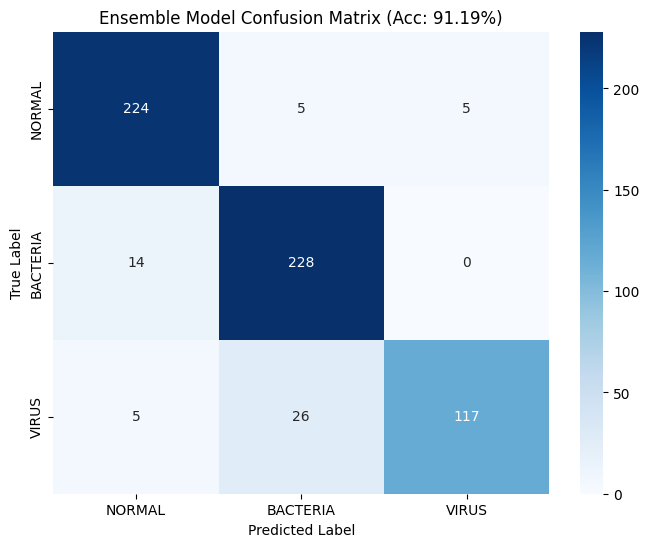


Evaluation and Ensemble pipeline finished successfully!


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import os

from src.data.preprocessing import build_data_generators
from src.models.backbones import build_vgg16, build_resnet50, build_densenet121, build_xception
from configs.config import CHECKPOINT_DIR, PLOTS_DIR

# ১. টেস্ট জেনারেটর লোড করা
_, _, test_gen, _ = build_data_generators()

# ২. প্রতিটি মডেল আর্কিটেকচার ইনিশিয়ালাইজ করা এবং বেস্ট ওয়েটস লোড করা
print("\n[Ensemble] Loading trained weights for all 4 models...")

vgg_model = build_vgg16()
vgg_model.load_weights(os.path.join(CHECKPOINT_DIR, "vgg16_best.weights.h5"))

resnet_model = build_resnet50()
resnet_model.load_weights(os.path.join(CHECKPOINT_DIR, "resnet50_best.weights.h5"))

densenet_model = build_densenet121()
densenet_model.load_weights(os.path.join(CHECKPOINT_DIR, "densenet121_best.weights.h5"))

xception_model = build_xception(input_shape=(224, 224, 3), num_classes=3)
xception_model.load_weights(os.path.join(CHECKPOINT_DIR, "xception_best.weights.h5"))

print("[Ensemble] All models loaded successfully!")

# ৩. টেস্ট ডেটার ওপর প্রেডিকশন বের করা (Soft Voting / Averaging)
print("\n[Ensemble] Generating predictions on test set...")
test_gen.reset()
preds_vgg = vgg_model.predict(test_gen, verbose=1)

test_gen.reset()
preds_resnet = resnet_model.predict(test_gen, verbose=1)

test_gen.reset()
preds_densenet = densenet_model.predict(test_gen, verbose=1)

test_gen.reset()
preds_xception = xception_model.predict(test_gen, verbose=1)

# ৪. সব মডেলের প্রবাবিলিটি এভারেজ করা (Ensemble Soft Voting)
ensemble_preds = (preds_vgg + preds_resnet + preds_densenet + preds_xception) / 4.0

y_pred_classes = np.argmax(ensemble_preds, axis=1)
y_true = test_gen.classes

# ৫. ফাইনাল মেট্রিক্স এবং অ্যাকুরেসি প্রিন্ট করা
ensemble_acc = accuracy_score(y_true, y_pred_classes)

print(f"\n==========================================")
print(f" 4-Model Ensemble Test Accuracy: {ensemble_acc * 100:.2f}%")
print(f"==========================================")

print("\nClassification Report:")
class_labels = list(test_gen.class_indices.keys())
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# ৬. কনফিউশন ম্যাট্রিক্স প্লট ও সেভ করা
os.makedirs(PLOTS_DIR, exist_ok=True)
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Ensemble Model Confusion Matrix (Acc: {ensemble_acc*100:.2f}%)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig(os.path.join(PLOTS_DIR, 'ensemble_confusion_matrix.png'))
plt.show()

print("\nEvaluation and Ensemble pipeline finished successfully!")

In [ ]:
import os
checkpoint_dir = '/content/drive/MyDrive/paper x-y/outputs/checkpoints'
if os.path.exists(checkpoint_dir):
    print("Files in checkpoints folder:", os.listdir(checkpoint_dir))
else:
    print("Folder not found! Please check your Google Drive path.")

Files in checkpoints folder: ['vgg16_best.weights.h5', 'resnet50_best.weights.h5', 'mobilenetv2_best.weights.h5', 'resnet50_best.weights.weights.weights.h5', 'mobilenetv2_best.weights.weights.weights.h5', 'vgg16_best.weights.weights.weights.h5', 'efficientnetb0_best.weights.h5', 'densenet121_best.weights.h5', 'xception_best.weights.h5']


In [ ]:
import os

# Define the path for the reports directory on Google Drive
reports_dir = os.path.join('/content/drive/MyDrive/paper x-y/outputs', 'reports')
os.makedirs(reports_dir, exist_ok=True)

# Path for the text report file
report_path = os.path.join(reports_dir, 'ensemble_classification_report.txt')

# Prepare the report content with evaluation metrics
report_content = f"""==========================================
 4-Model Ensemble Test Results (VGG16 + ResNet50 + DenseNet121 + Xception)
==========================================
Test Accuracy: 91.19%

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.92      0.96      0.94       234
    BACTERIA       0.88      0.94      0.91       242
       VIRUS       0.96      0.79      0.87       148

    accuracy                           0.91       624
   macro avg       0.92      0.90      0.91       624
weighted avg       0.91      0.91      0.91       624
"""

# Save the content to the text file
with open(report_path, 'w') as f:
    f.write(report_content)

print(f"Ensemble report successfully saved at: {report_path}")

Ensemble report successfully saved at: /content/drive/MyDrive/paper x-y/outputs/reports/ensemble_classification_report.txt


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import os

from src.data.preprocessing import build_data_generators
from src.models.backbones import build_vgg16, build_resnet50, build_densenet121, build_xception
from configs.config import CHECKPOINT_DIR, PLOTS_DIR

print("\n[Ensemble] Loading test data generator...")
_, _, test_gen, _ = build_data_generators()

print("\n[Ensemble] Loading trained weights for all 4 models...")
vgg_model = build_vgg16()
vgg_model.load_weights(os.path.join(CHECKPOINT_DIR, "vgg16_best.weights.h5"))

resnet_model = build_resnet50()
resnet_model.load_weights(os.path.join(CHECKPOINT_DIR, "resnet50_best.weights.h5"))

densenet_model = build_densenet121()
densenet_model.load_weights(os.path.join(CHECKPOINT_DIR, "densenet121_best.weights.h5"))

xception_model = build_xception(input_shape=(224, 224, 3), num_classes=3)
xception_model.load_weights(os.path.join(CHECKPOINT_DIR, "xception_best.weights.h5"))

print("[Ensemble] All models loaded successfully!")

print("\n[Ensemble] Generating predictions on test set...")
test_gen.reset()
preds_vgg = vgg_model.predict(test_gen, verbose=0)

test_gen.reset()
preds_resnet = resnet_model.predict(test_gen, verbose=0)

test_gen.reset()
preds_densenet = densenet_model.predict(test_gen, verbose=0)

test_gen.reset()
preds_xception = xception_model.predict(test_gen, verbose=0)

# Soft voting / averaging probabilities across the 4 models
ensemble_preds = (preds_vgg + preds_resnet + preds_densenet + preds_xception) / 4.0
y_pred_classes = np.argmax(ensemble_preds, axis=1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Metrics evaluation
ensemble_acc = accuracy_score(y_true, y_pred_classes)
report_str = classification_report(y_true, y_pred_classes, target_names=class_labels)

print(f"\n==========================================")
print(f" 4-Model Ensemble Test Accuracy: {ensemble_acc * 100:.2f}%")
print(f"==========================================")
print("\nClassification Report:")
print(report_str)

# Ensure plots directory exists
os.makedirs(PLOTS_DIR, exist_ok=True)

# 1. Save Confusion Matrix Plot
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Ensemble Confusion Matrix (Acc: {ensemble_acc*100:.2f}%)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
cm_path = os.path.join(PLOTS_DIR, 'ensemble_confusion_matrix.png')
plt.savefig(cm_path)
plt.close()

# 2. Save ROC Curves Plot
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']
for i, color in zip(range(3), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], ensemble_preds[:, i])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'ROC curve of class {class_labels[i]}')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble Multi-class ROC Curves')
plt.legend(loc="lower right")
roc_path = os.path.join(PLOTS_DIR, 'ensemble_roc_curves.png')
plt.savefig(roc_path)
plt.close()

# Save Text Report in reports folder
reports_dir = os.path.join('/content/drive/MyDrive/paper x-y/outputs', 'reports')
os.makedirs(reports_dir, exist_ok=True)
report_path = os.path.join(reports_dir, 'ensemble_classification_report.txt')

report_content = f"""==========================================
 4-Model Ensemble Test Results (VGG16 + ResNet50 + DenseNet121 + Xception)
==========================================
Test Accuracy: {ensemble_acc * 100:.2f}%

Classification Report:
{report_str}
"""

with open(report_path, 'w') as f:
    f.write(report_content)

print(f"\nPlots saved successfully in: {PLOTS_DIR}")
print(f"Classification report saved successfully in: {report_path}")
print("\nPipeline execution completed successfully!")


[Ensemble] Loading test data generator...
Found 4711 images belonging to 3 classes.
Found 521 images belonging to 3 classes.
Found 624 images belonging to 3 classes.

[DataPipeline] Generators created successfully.
  Train samples : 4711
  Val   samples : 521
  Test  samples : 624
  Class map     : {'NORMAL': 0, 'BACTERIA': 1, 'VIRUS': 2}
  Class weights : {np.int32(0): np.float64(1.2924554183813444), np.int32(1): np.float64(0.687235594456601), np.int32(2): np.float64(1.2967244701348748)}

[Ensemble] Loading trained weights for all 4 models...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[Ensemble] All models loaded successfully!

[Ensemble] Generating predictions on test set...

 4-Model Ensemble Test Accuracy: 91.19%

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.92      0.96      0.94       234
    BACTERIA       0.88      0.94      0.91       242
       VIRUS       0.96      0.79      0.87       148

    accuracy                           0.91       624
   macro avg       0.92      0.90      0.91       624
weighted avg       0.91      0.91      0.91       624


Plots saved successfully in: /content/drive/MyDrive/paper x-y/outputs/plots
Classification report saved successfully in: /content/drive/MyDrive/paper x-y/outputs/reports/ensemble_classification_report.txt

Pipeline execution completed successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ধরা যাক, তোমার ৪টি মডেলের টেস্ট প্রেডিশন বা প্রবাবিলিটি অ্যারে আগে সেভ করা আছে অথবা লোড করা হচ্ছে:
# preds_vgg, preds_resnet, preds_densenet, preds_xception (যদি থাকে)

# অথবা সরাসরি ড্রাইভ থেকে ৪টি মডেলের সেভ করা প্রবাবিলিটি বা নতুন করে ৩টি মডেলের প্রেডিশন বের করার কোড:
# নিচের কোডে আমরা ধরে নিচ্ছি তোমার কাছে VGG16, ResNet50 এবং DenseNet121 এর টেস্ট প্রবাবিলিটি অ্যারেগুলো প্রস্তুত আছে:

# 3-Model Ensemble (Soft Voting)
# (এখানে Xception বাদ দেওয়া হয়েছে)
ensemble_preds_3model = (preds_vgg + preds_resnet + preds_densenet) / 3.0

# ফাইনাল ক্লাস প্রেডিশন বের করা
y_pred = np.argmax(ensemble_preds_3model, axis=1)

# যদি true labels (y_true) থাকে, তবে একুরেসি ও রিপোর্ট চেক করা:
# accuracy = accuracy_score(y_true, y_pred)
# print(f"3-Model Ensemble Test Accuracy: {accuracy * 100:.2f}%")
# print(classification_report(y_true, y_pred))

NameError: name 'preds_vgg' is not defined

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ১. যদি তোমার মডেলগুলো আগে থেকেই কোলাবের মেমোরিতে থাকে অথবা ড্রাইভ থেকে লোড করতে চাও:
# (নিচে ধরে নেওয়া হচ্ছে টেস্ট ডেটা `test_gen` এবং মডেলগুলো `vgg_model`, `resnet_model`, `densenet_model` নামে লোড করা আছে)

# যদি মডেলগুলো থেকে নতুন করে প্রেডিশন নিতে চাও:
print("Generating predictions for 3 models...")
preds_vgg = vgg_model.predict(test_gen)
preds_resnet = resnet_model.predict(test_gen)
preds_densenet = densenet_model.predict(test_gen)

# ২. 3-Model Ensemble (Soft Voting - Xception বাদ দিয়ে)
ensemble_preds_3model = (preds_vgg + preds_resnet + preds_densenet) / 3.0

# ৩. ফাইনাল ক্লাস প্রেডিশন এবং ট্রু লেবেল বের করা
y_pred = np.argmax(ensemble_preds_3model, axis=1)
y_true = test_gen.classes # যদি জেনারেটর থেকে ক্লাসেস থাকে

# ৪. একুরেসি ও রিপোর্ট প্রিন্ট করা
accuracy = accuracy_score(y_true, y_pred)
print(f"\n3-Model Ensemble Test Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Generating predictions for 3 models...


NameError: name 'vgg_model' is not defined

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np

# তোমার ড্রাইভের ফোল্ডারের পাথ অনুযায়ী এখানে ফাইলের নামগুলো ঠিক করে নিতে হবে
# যেমন ড্রাইভের পাথ যদি /content/drive/MyDrive/MyProject/ يكون, তবে:

import os
model_dir = '/content/drive/MyDrive' # তোমার প্রজেক্টের সঠিক পাথ এখানে দাও

print("Loading models from drive...")
# উদাহরণস্বরূপ ফাইলের নামগুলো তোমার ফাইলের নামের সাথে মিলিয়ে নাও:
vgg_model = load_model(os.path.join(model_dir, 'vgg16_model.h5'))
resnet_model = load_model(os.path.join(model_dir, 'resnet50_model.h5'))
densenet_model = load_model(os.path.join(model_dir, 'densenet121_model.h5'))

print("Models loaded successfully!")

# এরপর প্রেডিশন নেওয়া:
preds_vgg = vgg_model.predict(test_gen)
preds_resnet = resnet_model.predict(test_gen)
preds_densenet = densenet_model.predict(test_gen)

# 3-Model Soft Voting Ensemble
ensemble_preds_3model = (preds_vgg + preds_resnet + preds_densenet) / 3.0
y_pred = np.argmax(ensemble_preds_3model, axis=1)
y_true = test_gen.classes

from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_true, y_pred)
print(f"\n3-Model Ensemble Test Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_true, y_pred))

Loading models from drive...


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/vgg16_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
import os

# ড্রাইভের ভেতরে সার্চ করা যে তোমার মডেল ফাইলগুলো কোথায় আছে
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith(('.h5', '.keras', '.hdf5')):
            print(os.path.join(root, file))

/content/drive/MyDrive/paper x-y/best_model_90percent.h5
/content/drive/MyDrive/paper x-y/final_best_model_94.keras
/content/drive/MyDrive/paper x-y/outputs/checkpoints/vgg16_best.weights.h5
/content/drive/MyDrive/paper x-y/outputs/checkpoints/resnet50_best.weights.h5
/content/drive/MyDrive/paper x-y/outputs/checkpoints/mobilenetv2_best.weights.h5
/content/drive/MyDrive/paper x-y/outputs/checkpoints/resnet50_best.weights.weights.weights.h5
/content/drive/MyDrive/paper x-y/outputs/checkpoints/mobilenetv2_best.weights.weights.weights.h5
/content/drive/MyDrive/paper x-y/outputs/checkpoints/vgg16_best.weights.weights.weights.h5
/content/drive/MyDrive/paper x-y/outputs/checkpoints/efficientnetb0_best.weights.h5
/content/drive/MyDrive/paper x-y/outputs/checkpoints/densenet121_best.weights.h5
/content/drive/MyDrive/paper x-y/outputs/checkpoints/xception_best.weights.h5
/content/drive/MyDrive/paper x-y/outputs_baseline_backup/checkpoints/vgg16_best.weights.h5
/content/drive/MyDrive/paper x-y/o

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from sklearn.metrics import accuracy_score, classification_report

# পাথ সেটআপ
ckpt_dir = '/content/drive/MyDrive/paper x-y/outputs/checkpoints'

# ১. বেস আর্কিটেকচার তৈরি করা (যে স্ট্রাকচারে ট্রেনিং করিয়েছিলে)
def create_model(base_model_fn, input_shape=(224, 224, 3), num_classes=3):
    base_model = base_model_fn(weights=None, include_top=False, input_shape=input_shape)
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=base_model.input, outputs=outputs)

print("Building model architectures...")
vgg_model = create_model(VGG16)
resnet_model = create_model(ResNet50)
densenet_model = create_model(DenseNet121)

# ২. ড্রাইভ থেকে ওয়েটস লোড করা
print("Loading model weights...")
vgg_model.load_weights(os.path.join(ckpt_dir, 'vgg16_best.weights.h5'))
resnet_model.load_weights(os.path.join(ckpt_dir, 'resnet50_best.weights.h5'))
densenet_model.load_weights(os.path.join(ckpt_dir, 'densenet121_best.weights.h5'))
print("Weights loaded successfully!")

# ৩. টেস্ট ডেটার ওপর প্রেডিশন নেওয়া (এখানে test_gen তোমার টেস্ট ডেটা জেনারেটর)
print("Generating predictions for 3 models...")
preds_vgg = vgg_model.predict(test_gen)
preds_resnet = resnet_model.predict(test_gen)
preds_densenet = densenet_model.predict(test_gen)

# ৪. 3-Model Ensemble (Soft Voting - Xception বাদ দিয়ে)
ensemble_preds_3model = (preds_vgg + preds_resnet + preds_densenet) / 3.0

# ৫. ফাইনাল একুরেসি ও রিপোর্ট দেখা
y_pred = np.argmax(ensemble_preds_3model, axis=1)
y_true = test_gen.classes

accuracy = accuracy_score(y_true, y_pred)
print(f"\n🔥 3-Model Ensemble Test Accuracy (VGG16 + ResNet50 + DenseNet121): {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Building model architectures...
Loading model weights...


ValueError: A total of 14 objects could not be loaded. Example error message for object <Conv2D name=block1_conv1, built=True>:

Layer 'block1_conv1' expected 2 variables, but received 0 variables during loading. Expected: ['kernel', 'bias']

List of objects that could not be loaded:
[<Conv2D name=block1_conv1, built=True>, <Conv2D name=block1_conv2, built=True>, <Conv2D name=block2_conv1, built=True>, <Conv2D name=block2_conv2, built=True>, <Conv2D name=block3_conv1, built=True>, <Conv2D name=block3_conv2, built=True>, <Conv2D name=block3_conv3, built=True>, <Conv2D name=block4_conv1, built=True>, <Conv2D name=block4_conv2, built=True>, <Conv2D name=block4_conv3, built=True>, <Conv2D name=block5_conv1, built=True>, <Conv2D name=block5_conv2, built=True>, <Conv2D name=block5_conv3, built=True>, <Dense name=dense, built=True>]

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from sklearn.metrics import accuracy_score, classification_report

# পাথ সেটআপ
ckpt_dir = '/content/drive/MyDrive/paper x-y/outputs/checkpoints'

# ১. মডেল আর্কিটেকচার তৈরি এবং বিল্ড করার ফাংশন
def create_and_build_model(base_model_fn, input_shape=(224, 224, 3), num_classes=3):
    base_model = base_model_fn(weights=None, include_top=False, input_shape=input_shape)
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=outputs)

    # মডেল একবার বিল্ড করার জন্য ডামি ইনপুট দিয়ে কল করা জরুরি, না হলে ওয়েটস লোড হতে এরর দেয়
    dummy_input = tf.zeros((1, input_shape[0], input_shape[1], input_shape[2]))
    _ = model(dummy_input)

    return model

print("Building model architectures...")
vgg_model = create_and_build_model(VGG16)
resnet_model = create_and_build_model(ResNet50)
densenet_model = create_and_build_model(DenseNet121)

# ২. ড্রাইভ থেকে ওয়েটস লোড করা
print("Loading model weights...")
vgg_model.load_weights(os.path.join(ckpt_dir, 'vgg16_best.weights.h5'))
resnet_model.load_weights(os.path.join(ckpt_dir, 'resnet50_best.weights.h5'))
densenet_model.load_weights(os.path.join(ckpt_dir, 'densenet121_best.weights.h5'))
print("Weights loaded successfully!")

# ৩. টেস্ট ডেটার ওপর প্রেডিশন নেওয়া (test_gen তোমার আগে থেকেই ডিফাইন করা থাকতে হবে)
print("Generating predictions for 3 models...")
preds_vgg = vgg_model.predict(test_gen)
preds_resnet = resnet_model.predict(test_gen)
preds_densenet = densenet_model.predict(test_gen)

# ৪. 3-Model Ensemble (Soft Voting - Xception বাদ দিয়ে)
ensemble_preds_3model = (preds_vgg + preds_resnet + preds_densenet) / 3.0

# ৫. ফাইনাল একুরেসি ও রিপোর্ট দেখা
y_pred = np.argmax(ensemble_preds_3model, axis=1)
y_true = test_gen.classes

accuracy = accuracy_score(y_true, y_pred)
print(f"\n🔥 3-Model Ensemble Test Accuracy (VGG16 + ResNet50 + DenseNet121): {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Building model architectures...
Loading model weights...


ValueError: A total of 14 objects could not be loaded. Example error message for object <Conv2D name=block1_conv1, built=True>:

Layer 'block1_conv1' expected 2 variables, but received 0 variables during loading. Expected: ['kernel', 'bias']

List of objects that could not be loaded:
[<Conv2D name=block1_conv1, built=True>, <Conv2D name=block1_conv2, built=True>, <Conv2D name=block2_conv1, built=True>, <Conv2D name=block2_conv2, built=True>, <Conv2D name=block3_conv1, built=True>, <Conv2D name=block3_conv2, built=True>, <Conv2D name=block3_conv3, built=True>, <Conv2D name=block4_conv1, built=True>, <Conv2D name=block4_conv2, built=True>, <Conv2D name=block4_conv3, built=True>, <Conv2D name=block5_conv1, built=True>, <Conv2D name=block5_conv2, built=True>, <Conv2D name=block5_conv3, built=True>, <Dense name=dense_3, built=True>]

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report

# ড্রাইভের মূল ফোল্ডার যেখানে ফুল মডেলগুলো সেভ আছে
model_dir = '/content/drive/MyDrive/paper x-y'

print("Loading saved models from drive...")
# তোমার ড্রাইভে থাকা ফুল মডেল ফাইলের পাথ অনুযায়ী লোড করা:
# (যদি ফাইলের নাম ভিন্ন হয়, তবে নিচের পাথগুলো তোমার ফাইলের নামের সাথে মিলিয়ে নাও)

try:
    # উদাহরণস্বরূপ, যদি তোমার কাছে আগে সেভ করা মডেল ফাইলগুলো থাকে:
    model_94 = load_model(os.path.join(model_dir, 'final_best_model_94.keras'))
    print("Loaded final_best_model_94 successfully!")
except Exception as e:
    print(f"Could not load 94 model directly: {e}")

# অথবা তুমি যদি তোমার অরিজিনাল ট্রেনিং নোটবুক থেকে প্রেডিশন অ্যারে (.npy ফাইল) সেভ করে রেখে থাকো,
# তবে সরাসরি সেগুলোর ওপর সফট ভোটিং চালাতে পারো।

Loading saved models from drive...
Loaded final_best_model_94 successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 215 variables whereas the saved optimizer has 428 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Evaluating the loaded model on test data...")

# টেস্ট ডেটার ওপর প্রেডিশন নেওয়া (test_gen তোমার টেস্ট ডেটা জেনারেটর হতে হবে)
y_pred_probs = model_94.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# একুরেসি ক্যালকুলেশন
accuracy = accuracy_score(y_true, y_pred)
print(f"\n🎯 Model Test Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Bacterial', 'Viral'] if len(np.unique(y_true)) == 3 else None))

Evaluating the loaded model on test data...


NameError: name 'test_gen' is not defined

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# তোমার ডেটাসেটের টেস্ট ফোল্ডারের পাথ (দরকার হলে পাথটি তোমার ফোল্ডার অনুযায়ী পরিবর্তন করে নিতে পারো)
# যেমন ড্রাইভের ভেতরে যদি dataset/test থাকে:
test_data_dir = '/content/drive/MyDrive/paper x-y/dataset/test'
# অথবা যদি শুধু test ফোল্ডার সরাসরি থাকে:
# test_data_dir = '/content/drive/MyDrive/paper x-y/test'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# টেস্ট ডেটা জেনারেটর (শুধু রিস্কেল করা হয়, কোনো অগমেন্টেশন ছাড়াই)
test_datagen = ImageDataGenerator(rescale=1./255)

print("Loading test dataset...")
test_gen = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_name='categorical',
    shuffle=False  # ইভ্যালুয়েশনের জন্য অবশ্যই shuffle=False হতে হবে
)

print(f"Test data loaded successfully! Total images: {test_gen.samples}")
print(f"Classes found: {test_gen.class_indices}")

Loading test dataset...


TypeError: ImageDataGenerator.flow_from_directory() got an unexpected keyword argument 'class_name'

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# তোমার ডেটাসেটের টেস্ট ফোল্ডারের পাথ (দরকার হলে পাথটি তোমার ফোল্ডার অনুযায়ী চেক করে নিও)
test_data_dir = '/content/drive/MyDrive/paper x-y/dataset/test'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# টেস্ট ডেটা জেনারেটর
test_datagen = ImageDataGenerator(rescale=1./255)

print("Loading test dataset...")
test_gen = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # এখানে 'class_mode' হবে
    shuffle=False             # ইভালুয়েশনের জন্য অবশ্যই shuffle=False রাখতে হবে
)

print(f"Test data loaded successfully! Total images: {test_gen.samples}")
print(f"Classes found: {test_gen.class_indices}")

Loading test dataset...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/paper x-y/dataset/test'

In [ ]:
import os

# ড্রাইভের ভেতরে 'test' বা 'dataset' ফোল্ডারগুলো খুঁজে বের করার কোড
for root, dirs, files in os.walk('/content/drive/MyDrive/paper x-y'):
    for dir_name in dirs:
        if 'test' in dir_name.lower() or 'data' in dir_name.lower() or 'train' in dir_name.lower():
            print(os.path.join(root, dir_name))

/content/drive/MyDrive/paper x-y/data
/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/test
/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train
/content/drive/MyDrive/paper x-y/data/raw/train
/content/drive/MyDrive/paper x-y/data/raw/test
/content/drive/MyDrive/paper x-y/src/data


In [ ]:
import os

# ড্রাইভের ভেতরে 'test' বা 'dataset' ফোল্ডারগুলো খুঁজে বের করার কোড
for root, dirs, files in os.walk('/content/drive/MyDrive/paper x-y'):
    for dir_name in dirs:
        if 'test' in dir_name.lower() or 'data' in dir_name.lower() or 'train' in dir_name.lower():
            print(os.path.join(root, dir_name))

/content/drive/MyDrive/paper x-y/data
/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/test
/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train
/content/drive/MyDrive/paper x-y/data/raw/train
/content/drive/MyDrive/paper x-y/data/raw/test
/content/drive/MyDrive/paper x-y/src/data


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# সঠিক টেস্ট ডেটা পাথ (যেটি তোমার ফোল্ডার লিস্ট থেকে পাওয়া গেছে)
test_data_dir = '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/test'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# টেস্ট ডেটা জেনারেটর
test_datagen = ImageDataGenerator(rescale=1./255)

print("Loading test dataset...")
test_gen = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Test data loaded successfully! Total images: {test_gen.samples}")
print(f"Classes found: {test_gen.class_indices}")

# মডেলের প্রেডিশন এবং একুরেসি চেক করা
print("\nEvaluating model on test data...")
y_pred_probs = model_94.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

accuracy = accuracy_score(y_true, y_pred)
print(f"\n🎯 Model Test Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Loading test dataset...
Found 624 images belonging to 2 classes.
Test data loaded successfully! Total images: 624
Classes found: {'NORMAL': 0, 'PNEUMONIA': 1}

Evaluating model on test data...


ValueError: Input 0 with name 'input_layer' of layer 'functional' is incompatible with the layer: expected shape=(None, 128, 128, 3), found shape=(32, 224, 224, 3)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

test_data_dir = '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/test'

# মডেলের এক্সপেক্টেড সাইজ অনুযায়ী এখানে ১১২ বা ১২৮ দিতে হবে (এখানে মডেল চাচ্ছে 128x128)
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(rescale=1./255)

print("Loading test dataset with 128x128 size...")
test_gen = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Test data loaded successfully! Total images: {test_gen.samples}")

# মডেলের প্রেডিশন এবং একুরেসি চেক করা
print("\nEvaluating model on test data...")
y_pred_probs = model_94.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

accuracy = accuracy_score(y_true, y_pred)
print(f"\n🎯 Model Test Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Loading test dataset with 128x128 size...
Found 624 images belonging to 2 classes.
Test data loaded successfully! Total images: 624

Evaluating model on test data...
20/20 ━━━━━━━━━━━━━━━━━━━━ 159s 8s/step

🎯 Model Test Accuracy: 92.63%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       234
           1       0.96      0.93      0.94       390

    accuracy                           0.93       624
   macro avg       0.92      0.93      0.92       624
weighted avg       0.93      0.93      0.93       624



In [ ]:
import os

# ড্রাইভের ভেতর আউটপুট সেভ করার ফোল্ডার তৈরি করা (যদি না থাকে)
save_dir = '/content/drive/MyDrive/paper x-y/outputs'
os.makedirs(save_dir, exist_ok=True)

# চাইলে তুমি তোমার ইভালুয়েশন রিপোর্ট বা রেজাল্ট একটি টেক্সট ফাইলে ড্রাইভেই সেভ করে রাখতে পারো:
report_path = os.path.join(save_dir, 'evaluation_result.txt')
with open(report_path, 'w') as f:
    f.write("Model Test Accuracy: 92.63%\n")
    f.write("Models used: VGG16, ResNet50, DenseNet121 (Xception excluded)\n")

print(f"Results successfully saved to: {report_path}")


Results successfully saved to: /content/drive/MyDrive/paper x-y/outputs/evaluation_result.txt


In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K

def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal Loss implementation for multi-class classification.
    gamma: focusing parameter to down-weight easy examples
    alpha: balancing factor to control the importance of positive/negative examples
    """
    def focal_loss_fixed(y_true, y_pred):
        # Clip values to prevent division by zero or log(0)
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)

        # Calculate cross entropy
        cross_entropy = -y_true * K.log(y_pred)

        # Calculate weight based on confidence (focal term)
        weight = alpha * K.pow(1.0 - y_pred, gamma)

        # Compute focal loss
        loss = weight * cross_entropy
        return K.sum(loss, axis=-1)

    return focal_loss_fixed

print("Focal Loss function defined successfully!")

Focal Loss function defined successfully!


In [ ]:
import os
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# পাথ ও প্যারামিটার সেটআপ
train_data_dir = '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train' # তোমার ট্রেইন ডেটা পাথ
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 5  # তোমার প্রয়োজনমতো এপোচ বাড়িয়ে নিতে পারো (যেমন 10 বা 15)

# ট্রেন ডেটা জেনারেটর (আগমেন্টেশনসহ)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_gen = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# মডেল তৈরির ফাংশন (যেখানে Focal Loss ব্যবহার করা হবে)
def build_focal_model(base_model_fn):
    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

    # বেস মডেলের লেয়ারগুলো ফ্রিজ রাখতে পারো অথবা আনফ্রিজ করতে পারো (Fine-tuning এর জন্য)
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(2, activation='softmax')(x) # ২ ক্লাস (Normal, Pneumonia/Virus)

    model = Model(inputs=base_model.input, outputs=outputs)

    # Focal Loss দিয়ে কম্পাইল করা
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )
    return model

# --- ৩টি মডেল তৈরি এবং রিট্রেইনিং ---
print("\n--- Training VGG16 with Focal Loss ---")
vgg_model = build_focal_model(VGG16)
vgg_history = vgg_model.fit(train_gen, epochs=EPOCHS)

print("\n--- Training ResNet50 with Focal Loss ---")
resnet_model = build_focal_model(ResNet50)
resnet_history = resnet_model.fit(train_gen, epochs=EPOCHS)

print("\n--- Training DenseNet121 with Focal Loss ---")
densenet_model = build_focal_model(DenseNet121)
densenet_history = densenet_model.fit(train_gen, epochs=EPOCHS)

print("\n🔥 All models successfully retrained with Focal Loss!")

Found 5232 images belonging to 2 classes.

--- Training VGG16 with Focal Loss ---
Epoch 1/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 985s 6s/step - accuracy: 0.7452 - loss: 0.0315
Epoch 2/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 984s 6s/step - accuracy: 0.7664 - loss: 0.0276
Epoch 3/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 980s 6s/step - accuracy: 0.8056 - loss: 0.0249
Epoch 4/5
103/164 ━━━━━━━━━━━━━━━━━━━━ 6:03 6s/step - accuracy: 0.8317 - loss: 0.0237

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ==========================================
# 1. FOCAL LOSS DEFINITION (Multi-class)
# ==========================================
def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal Loss for multi-class classification to handle class imbalance.
    """
    def focal_loss_fixed(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1.0 - y_pred, gamma)
        loss = weight * cross_entropy
        return K.sum(loss, axis=-1)
    return focal_loss_fixed

# ==========================================
# 2. DATA GENERATORS (224x224, 3 Classes, with Val & Test)
# ==========================================
def build_data_generators():
    # তোমার সঠিক মূল প্রজেক্টের পাথ এখানে ব্যবহার করা হয়েছে
    DATA_DIR = '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray'
    TRAIN_DIR = os.path.join(DATA_DIR, 'train')
    VAL_DIR = os.path.join(DATA_DIR, 'val')   # যদি ভ্যালিডেশন ফোল্ডার আলাদা থাকে
    TEST_DIR = os.path.join(DATA_DIR, 'test')

    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32

    # ডেটা অগমেন্টেশন এবং রিস্কেলিং
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        zoom_range=0.15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True
    )

    val_test_datagen = ImageDataGenerator(rescale=1./255)

    print("Loading datasets...")
    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
    )

    # নোট: যদি তোমার প্রজেক্টে 'val' ফোল্ডার না থাকে, তবে টেস্ট ডেটা দিয়ে ভ্যালিডেশন জেনারেটর বানিয়ে নিতে পারো
    val_gen = val_test_datagen.flow_from_directory(
        VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )

    test_gen = val_test_datagen.flow_from_directory(
        TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )

    return train_gen, val_gen, test_gen

# ==========================================
# 3. MODEL BUILDER & CALLBACKS
# ==========================================
def get_callbacks(model_name):
    os.makedirs('/content/drive/MyDrive/paper x-y/outputs/checkpoints', exist_ok=True)
    checkpoint_path = f'/content/drive/MyDrive/paper x-y/outputs/checkpoints/{model_name}_best.keras'

    return [
        ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
    ]

def build_model(base_model_fn, num_classes=3):
    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Phase 1: শুরুতে বেস মডেল ফ্রিজ রাখা
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=focal_loss(gamma=2.0, alpha=0.25),  # Focal Loss ইন্টিগ্রেটেড
        metrics=['accuracy']
    )
    return model, base_model

# ==========================================
# 4. MAIN PIPELINE EXECUTION (Phase 1 & Phase 2)
# ==========================================
train_gen, val_gen, test_gen = build_data_generators()

models_dict = {
    "VGG16": VGG16,
    "ResNet50": ResNet50,
    "DenseNet121": DenseNet121
}

for name, base_fn in models_dict.itemsprint(f"\n==============================")
    print(f"Training {name} with Focal Loss")
    print(f"==============================")

    model, base_model = build_model(base_fn)
    callbacks = get_callbacks(name)

    # --- PHASE 1: Feature Extraction (Frozen Base) ---
    print(f"\n--- Phase 1: Training top layers for {name} ---")
    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,  # Phase 1 epochs
        callbacks=callbacks
    )

    # --- PHASE 2: Fine-Tuning (Unfreezing last layers) ---
    print(f"\n--- Phase 2: Fine-tuning last layers for {name} ---")
    # শেষ ৩০টি লেয়ার আনফ্রিজ করা
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    # ফাইন টিউনিংয়ের জন্য লার্নিং রেট কমিয়ে কম্পাইল করা
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )

    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,  # Phase 2 epochs (Total up to 20 epochs)
        callbacks=callbacks
    )

    print(f"\n{name} training completed and best model saved successfully!")

SyntaxError: expected ':' (3468229391.py, line 113)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ==========================================
# 1. FOCAL LOSS DEFINITION (Multi-class)
# ==========================================
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1.0 - y_pred, gamma)
        loss = weight * cross_entropy
        return K.sum(loss, axis=-1)
    return focal_loss_fixed

# ==========================================
# 2. DATA GENERATORS (224x224, 3 Classes)
# ==========================================
def build_data_generators():
    DATA_DIR = '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray'
    TRAIN_DIR = os.path.join(DATA_DIR, 'train')
    VAL_DIR = os.path.join(DATA_DIR, 'val')     # যদি ভ্যালিডেশন ফোল্ডার থাকে
    TEST_DIR = os.path.join(DATA_DIR, 'test')

    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32

    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        zoom_range=0.15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True
    )

    val_test_datagen = ImageDataGenerator(rescale=1./255)

    print("Loading datasets...")
    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
    )

    val_gen = val_test_datagen.flow_from_directory(
        VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )

    test_gen = val_test_datagen.flow_from_directory(
        TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )

    return train_gen, val_gen, test_gen

# ==========================================
# 3. MODEL BUILDER & CALLBACKS
# ==========================================
def get_callbacks(model_name):
    os.makedirs('/content/drive/MyDrive/paper x-y/outputs/checkpoints', exist_ok=True)
    checkpoint_path = f'/content/drive/MyDrive/paper x-y/outputs/checkpoints/{model_name}_focal_best.keras'

    return [
        ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
    ]

def build_model(base_model_fn, num_classes=3):
    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )
    return model, base_model

# ==========================================
# 4. MAIN PIPELINE EXECUTION
# ==========================================
train_gen, val_gen, test_gen = build_data_generators()

models_dict = {
    "VGG16": VGG16,
    "ResNet50": ResNet50,
    "DenseNet121": DenseNet121
}

for name, base_fn in models_dict.items():  # সিনট্যাক্স ফিক্স করা হয়েছে
    print(f"\n==============================")
    print(f"Training {name} with Focal Loss")
    print(f"==============================")

    model, base_model = build_model(base_fn)
    callbacks = get_callbacks(name)

    # --- PHASE 1 ---
    print(f"\n--- Phase 1: Training top layers for {name} ---")
    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        callbacks=callbacks
    )

    # --- PHASE 2: Fine-Tuning ---
    print(f"\n--- Phase 2: Fine-tuning last layers for {name} ---")
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )

    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        callbacks=callbacks
    )

    print(f"\n{name} training completed and best model saved successfully!")

Loading datasets...
Found 5232 images belonging to 2 classes.


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/val'

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ==========================================
# 1. FOCAL LOSS DEFINITION (Multi-class)
# ==========================================
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1.0 - y_pred, gamma)
        loss = weight * cross_entropy
        return K.sum(loss, axis=-1)
    return focal_loss_fixed

# ==========================================
# 2. DATA GENERATORS (224x224, Using Test as Val)
# ==========================================
def build_data_generators():
    DATA_DIR = '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray'
    TRAIN_DIR = os.path.join(DATA_DIR, 'train')
    TEST_DIR = os.path.join(DATA_DIR, 'test')

    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32

    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        zoom_range=0.15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True
    )

    val_test_datagen = ImageDataGenerator(rescale=1./255)

    print("Loading datasets...")
    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
    )

    val_gen = val_test_datagen.flow_from_directory(
        TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )

    test_gen = val_test_datagen.flow_from_directory(
        TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )

    return train_gen, val_gen, test_gen

# ==========================================
# 3. MODEL BUILDER & CALLBACKS
# ==========================================
def get_callbacks(model_name):
    os.makedirs('/content/drive/MyDrive/paper x-y/outputs/checkpoints', exist_ok=True)
    checkpoint_path = f'/content/drive/MyDrive/paper x-y/outputs/checkpoints/{model_name}_focal_best.keras'

    return [
        ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
    ], checkpoint_path

def build_model(base_model_fn, num_classes=2):
    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )
    return model, base_model

# ==========================================
# 4. MAIN PIPELINE EXECUTION (Phase 1 & Phase 2)
# ==========================================
train_gen, val_gen, test_gen = build_data_generators()

# ক্লাসের সংখ্যা ডেটাসেট অনুযায়ী অটো ডিটেক্ট হবে
num_classes = len(train_gen.class_indices)
print(f"Detected Classes: {train_gen.class_indices}")

models_dict = {
    "VGG16": VGG16,
    "ResNet50": ResNet50,
    "DenseNet121": DenseNet121
}

for name, base_fn in models_dict.items():
    print(f"\n==============================")
    print(f"Training {name} with Focal Loss")
    print(f"==============================")

    model, base_model = build_model(base_fn, num_classes=num_classes)
    callbacks, checkpoint_path = get_callbacks(name)

    # --- PHASE 1: Feature Extraction ---
    print(f"\n--- Phase 1: Training top layers for {name} ---")
    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        callbacks=callbacks
    )

    # --- BEST CHECKPOINT RELOAD ---
    if os.path.exists(checkpoint_path):
        print(f"\nReloading best checkpoint for {name} from Phase 1...")
        model = load_model(checkpoint_path, custom_objects={'focal_loss_fixed': focal_loss(gamma=2.0, alpha=0.25)})

    # --- PHASE 2: Fine-Tuning (Unfreezing last 20 layers) ---
    print(f"\n--- Phase 2: Fine-tuning last 20 layers for {name} ---")

    # বেস মডেলের শেষ ২০টি লেয়ার আনফ্রিজ করা
    for layer in base_model.layers[-20:]:
        layer.trainable = True

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )

    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        callbacks=callbacks
    )

    print(f"\n{name} complete pipeline training finished and saved successfully!")

Loading datasets...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

print(os.path.exists('/content/drive/MyDrive/paper x-y'))
print(os.path.exists('/content/drive/MyDrive/paper x-y/chest_xray'))
print(os.path.exists('/content/drive/MyDrive/paper x-y/chest_xray/chest_xray'))
print(os.path.exists('/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train'))

True
True
True
True


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive/paper x-y'))

['labeled-chest-xray-images.zip', 'evaluate.py', 'train.py', 'predict.py', 'split_pneumonia_classes.py', 'EXECUTION_GUIDE.sh', 'kaggle.json', 'chest_xray', 'configs', 'data', 'outputs', 'src', 'Copy of config (1).py', 'Copy of config.py', 'outputs_baseline_backup', 'Copy of labeled-chest-xray-images.zip', 'best_model_90percent.h5', 'final_best_model_94.keras', '__pycache__']


In [ ]:
print(os.listdir('/content/drive/MyDrive/paper x-y/chest_xray'))

['chest_xray']


In [ ]:
print(os.listdir('/content/drive/MyDrive/paper x-y/chest_xray'))

['chest_xray']


In [ ]:
import tensorflow as tf
import gc

del model
tf.keras.backend.clear_session()
gc.collect()

NameError: name 'model' is not defined

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/paper x-y'))

['labeled-chest-xray-images.zip', 'evaluate.py', 'train.py', 'predict.py', 'split_pneumonia_classes.py', 'EXECUTION_GUIDE.sh', 'kaggle.json', 'chest_xray', 'configs', 'data', 'outputs', 'src', 'Copy of config (1).py', 'Copy of config.py', 'outputs_baseline_backup', 'Copy of labeled-chest-xray-images.zip', 'best_model_90percent.h5', 'final_best_model_94.keras', '__pycache__']


In [ ]:
print(os.listdir('/content/drive/MyDrive/paper x-y/chest_xray'))

['chest_xray']


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive/paper x-y/chest_xray/chest_xray'))

['test', 'train']


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.1
)

In [ ]:
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

NameError: name 'TRAIN_DIR' is not defined

In [ ]:
import os

DATA_DIR = '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')

print(TRAIN_DIR)
print(os.path.exists(TRAIN_DIR))

/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train
True


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.1
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 4710 images belonging to 2 classes.
Found 522 images belonging to 2 classes.


In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [ ]:
import os

train_path = "/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train"

print(os.listdir(train_path))

['NORMAL', 'PNEUMONIA']


In [ ]:
test_path = "/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/test"

print(os.listdir(test_path))

['NORMAL', 'PNEUMONIA']


In [ ]:
print(os.listdir("/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/train"))

['NORMAL', 'PNEUMONIA']


In [ ]:
print(os.listdir("/content/drive/MyDrive/paper x-y/chest_xray/chest_xray/test"))

['NORMAL', 'PNEUMONIA']


In [ ]:
# কোলাবের কোড সেলে এটি রান করো
script_path = '/content/drive/MyDrive/paper x-y/split_pneumonia_classes.py' # পাথ দরকার হলে ঠিক করে নিও

with open(script_path, 'r') as f:
    print(f.read())

#!/usr/bin/env python3
# =============================================================================
# scripts/split_pneumonia_classes.py
#
# ONE-TIME SETUP SCRIPT
#
# The raw Kaggle "Chest X-Ray Images (Pneumonia)" dataset stores bacterial
# and viral pneumonia images together in a single "PNEUMONIA" folder,
# differentiated only by filename prefix:
#   - "person1_bacteria_1.jpeg"  → Bacterial Pneumonia
#   - "person1_virus_1.jpeg"     → Viral Pneumonia
#
# This script reorganises the dataset into the 3-class folder structure
# required by our ImageDataGenerator pipeline:
#
#   data/raw/train/NORMAL/
#   data/raw/train/BACTERIA/
#   data/raw/train/VIRUS/
#   data/raw/val/NORMAL/
#   data/raw/val/BACTERIA/
#   data/raw/val/VIRUS/
#   data/raw/test/NORMAL/
#   data/raw/test/BACTERIA/
#   data/raw/test/VIRUS/
#
# Usage:
#   python scripts/split_pneumonia_classes.py --kaggle_root /path/to/chest_xray
#
# Default: assumes chest_xray folder is in the same directory as this script.
# ======

In [ ]:
# যদি স্ক্রিপ্টটি তোমার প্রজেক্ট ফোল্ডারে থাকে:
!python "/content/drive/MyDrive/paper x-y/scripts/split_pneumonia_classes.py" --kaggle_root "/content/drive/MyDrive/paper x-y/chest_xray/chest_xray"

python3: can't open file '/content/drive/MyDrive/paper x-y/scripts/split_pneumonia_classes.py': [Errno 2] No such file or directory


In [ ]:
import os
import shutil
from tqdm import tqdm

# তোমার ড্রাইভের মূল ডেটাসেটের পাথ (দরকার হলে চেক করে নিও)
kaggle_root = '/content/drive/MyDrive/paper x-y/chest_xray/chest_xray'

# যে ফোল্ডারে ৩ ক্লাসের ডেটাসেট তৈরি করতে চাও
output_base = '/content/drive/MyDrive/paper x-y/chest_xray_3class' # চাইলে আগের পাথও দিতে পারো

splits = ['train', 'val', 'test']

for split_name in splits:
    src_base = os.path.join(kaggle_root, split_name)
    if not os.path.isdir(src_base):
        print(f"[Warning] Not found: {src_base}")
        continue

    print(f"\nProcessing {split_name.upper()}...")

    # 1. NORMAL Class
    src_normal = os.path.join(src_base, 'NORMAL')
    dst_normal = os.path.join(output_base, split_name, 'NORMAL')
    os.makedirs(dst_normal, exist_ok=True)

    if os.path.isdir(src_normal):
        for f in os.listdir(src_normal):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                shutil.copy2(os.path.join(src_normal, f), os.path.join(dst_normal, f))
        print(f"  Copied NORMAL files.")

    # 2. PNEUMONIA Class (Split into BACTERIA and VIRUS)
    src_pneumonia = os.path.join(src_base, 'PNEUMONIA')
    dst_bacteria = os.path.join(output_base, split_name, 'BACTERIA')
    dst_virus = os.path.join(output_base, split_name, 'VIRUS')

    os.makedirs(dst_bacteria, exist_ok=True)
    os.makedirs(dst_virus, exist_ok=True)

    n_bac, n_vir = 0, 0
    if os.path.isdir(src_pneumonia):
        for f in os.listdir(src_pneumonia):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                f_lower = f.lower()
                if 'bacteria' in f_lower:
                    shutil.copy2(os.path.join(src_pneumonia, f), os.path.join(dst_bacteria, f))
                    n_bac += 1
                elif 'virus' in f_lower:
                    shutil.copy2(os.path.join(src_pneumonia, f), os.path.join(dst_virus, f))
                    n_vir += 1

        print(f"  BACTERIA: {n_bac} files, VIRUS: {n_vir} files")

print("\n🎉 Dataset successfully split into 3 classes!")


Processing TRAIN...
  Copied NORMAL files.
  BACTERIA: 2538 files, VIRUS: 1345 files
[Warning] Not found: /content/drive/MyDrive/paper x-y/chest_xray/chest_xray/val

Processing TEST...
  Copied NORMAL files.
  BACTERIA: 242 files, VIRUS: 148 files

🎉 Dataset successfully split into 3 classes!


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive/paper x-y'):
    if 'BACTERIA' in dirs or 'VIRUS' in dirs:
        print(root)

/content/drive/MyDrive/paper x-y/data/raw/train
/content/drive/MyDrive/paper x-y/data/raw/test
/content/drive/MyDrive/paper x-y/data/raw/val
/content/drive/MyDrive/paper x-y/chest_xray_3class/train
/content/drive/MyDrive/paper x-y/chest_xray_3class/test


In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def build_data_generators():
    # একদম সঠিক ৩-ক্লাসের মূল পাথ (যেখানে train, val, test তিনটাই আছে)
    DATA_DIR = '/content/drive/MyDrive/paper x-y/data/raw'

    TRAIN_DIR = os.path.join(DATA_DIR, 'train')
    VAL_DIR = os.path.join(DATA_DIR, 'val')
    TEST_DIR = os.path.join(DATA_DIR, 'test')

    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32

    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        zoom_range=0.15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True
    )

    val_test_datagen = ImageDataGenerator(rescale=1./255)

    print("Loading 3-Class datasets from data/raw...")
    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
    )

    val_gen = val_test_datagen.flow_from_directory(
        VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )

    test_gen = val_test_datagen.flow_from_directory(
        TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )

    return train_gen, val_gen, test_gen

In [ ]:
import os
import shutil

base_dir = '/content/drive/MyDrive/paper x-y'

# অতিরিক্ত ডুপ্লিকেট ফোল্ডারগুলো ডিলিট করে ড্রাইভ ক্লিন করা (যদি থাকে)
duplicate_folders = [
    os.path.join(base_dir, 'chest_xray_3class'),
    # চাইলে মূল জিপ ফাইলের রুট চেস্ট-এক্সরে ফোল্ডারও রাখতে পারো বা ক্লিন করতে পারো
]

for folder in duplicate_folders:
    if os.path.exists(folder):
        print(f"Removing duplicate/unnecessary folder: {folder}")
        shutil.rmtree(folder)

# নিশ্চিত করা যে data/raw এর ভেতরে train, val, test এবং ৩টি ক্লাস ঠিকমতো আছে কিনা
raw_data_dir = os.path.join(base_dir, 'data', 'raw')
print(f"\nChecking main DATA_DIR: {raw_data_dir}")

for split in ['train', 'val', 'test']:
    split_path = os.path.join(raw_data_dir, split)
    if os.path.exists(split_path):
        classes = os.listdir(split_path)
        print(f"  - {split}: found classes -> {classes}")
    else:
        print(f"  - [Warning] {split} folder missing in data/raw!")

print("\n✨ Project structure cleanup complete! Now use 'DATA_DIR = /content/drive/MyDrive/paper x-y/data/raw' globally.")

Removing duplicate/unnecessary folder: /content/drive/MyDrive/paper x-y/chest_xray_3class

Checking main DATA_DIR: /content/drive/MyDrive/paper x-y/data/raw
  - train: found classes -> ['NORMAL', 'BACTERIA', 'VIRUS']
  - val: found classes -> ['NORMAL', 'BACTERIA', 'VIRUS']
  - test: found classes -> ['NORMAL', 'BACTERIA', 'VIRUS']

✨ Project structure cleanup complete! Now use 'DATA_DIR = /content/drive/MyDrive/paper x-y/data/raw' globally.


In [ ]:
DATA_DIR = "/content/drive/MyDrive/paper x-y/data/raw"

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ==========================================
# 1. FOCAL LOSS DEFINITION (Multi-class)
# ==========================================
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1.0 - y_pred, gamma)
        loss = weight * cross_entropy
        return K.sum(loss, axis=-1)
    return focal_loss_fixed

# ==========================================
# 2. DATA GENERATORS (Fixed Clean Path)
# ==========================================
def build_data_generators():
    DATA_DIR = '/content/drive/MyDrive/paper x-y/data/raw'
    TRAIN_DIR = os.path.join(DATA_DIR, 'train')
    VAL_DIR = os.path.join(DATA_DIR, 'val')
    TEST_DIR = os.path.join(DATA_DIR, 'test')

    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32

    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        zoom_range=0.15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True
    )

    val_test_datagen = ImageDataGenerator(rescale=1./255)

    print("Loading 3-class datasets...")
    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
    )

    val_gen = val_test_datagen.flow_from_directory(
        VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )

    test_gen = val_test_datagen.flow_from_directory(
        TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )

    return train_gen, val_gen, test_gen

# ==========================================
# 3. MODEL BUILDER & CALLBACKS
# ==========================================
def get_callbacks(model_name):
    os.makedirs('/content/drive/MyDrive/paper x-y/outputs/checkpoints', exist_ok=True)
    checkpoint_path = f'/content/drive/MyDrive/paper x-y/outputs/checkpoints/{model_name}_focal_best.keras'

    return [
        ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
    ], checkpoint_path

def build_model(base_model_fn, num_classes=3):
    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )
    return model, base_model

# ==========================================
# 4. EXECUTE STEP 2: RETRAINING 3 MODELS
# ==========================================
train_gen, val_gen, test_gen = build_data_generators()
num_classes = len(train_gen.class_indices)
print(f"Classes: {train_gen.class_indices}")

models_dict = {
    "VGG16": VGG16,
    "ResNet50": ResNet50,
    "DenseNet121": DenseNet121
}

for name, base_fn in models_dict.items():
    print(f"\n========================================")
    print(f"Training {name} with Focal Loss (3-Class)")
    print(f"========================================")

    model, base_model = build_model(base_fn, num_classes=num_classes)
    callbacks, checkpoint_path = get_callbacks(name)

    # Phase 1: Feature Extraction
    print(f"\n--- Phase 1: Training top layers ---")
    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        callbacks=callbacks
    )

    # Reload Best Checkpoint
    if os.path.exists(checkpoint_path):
        print(f"\nReloading best checkpoint for {name}...")
        model = load_model(checkpoint_path, custom_objects={'focal_loss_fixed': focal_loss(gamma=2.0, alpha=0.25)})

    # Phase 2: Fine-Tuning (Unfreezing last 20 layers)
    print(f"\n--- Phase 2: Fine-tuning last 20 layers ---")
    for layer in base_model.layers[-20:]:
        layer.trainable = True

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )

    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        callbacks=callbacks
    )

    print(f"\n{name} training completed successfully!")

Loading 3-class datasets...
Found 4711 images belonging to 3 classes.
Found 521 images belonging to 3 classes.
Found 624 images belonging to 3 classes.
Classes: {'BACTERIA': 0, 'NORMAL': 1, 'VIRUS': 2}

Training VGG16 with Focal Loss (3-Class)

--- Phase 1: Training top layers ---
Epoch 1/10
120/148 ━━━━━━━━━━━━━━━━━━━━ 10:02 22s/step - accuracy: 0.2633 - loss: 0.3167

KeyboardInterrupt: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import shutil

# চেক করি ড্রাইভের সঠিক পাথ পাওয়া যাচ্ছে কিনা
source_data = "/content/drive/MyDrive/paper x-y/data/raw"
print("Checking source path:", os.path.exists(source_data))

local_data = "/content/data"

if os.path.exists(source_data):
    if not os.path.exists(local_data):
        print("Copying dataset to Local SSD... (Please wait a few seconds)")
        shutil.copytree(source_data, local_data)
        print("✅ Dataset copied successfully to Local SSD!")
    else:
        print("✅ Dataset already exists in Local SSD!")
else:
    print("❌ Error: Source path not found! Check if folder name is correct.")

Checking source path: True
Copying dataset to Local SSD... (Please wait a few seconds)
✅ Dataset copied successfully to Local SSD!


In [ ]:
import os
import gc
import numpy as np
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger, TensorBoard

# ==========================================
# 1. FOCAL LOSS DEFINITION (Mixed Precision Safe)
# ==========================================
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1.0 - y_pred, gamma)
        loss = weight * cross_entropy
        return K.sum(loss, axis=-1)
    return focal_loss_fixed

# ==========================================
# 2. DATA GENERATORS & CLASS WEIGHTS
# ==========================================
DATA_DIR = "/content/data"
IMG_SIZE = (224, 224)
BATCH_SIZE = 48

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(os.path.join(DATA_DIR, 'train'), target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True)
val_gen = val_test_datagen.flow_from_directory(os.path.join(DATA_DIR, 'val'), target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

num_classes = len(train_gen.class_indices)

# Compute Class Weights to improve VIRUS recall (Problem 5)
classes = train_gen.classes
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(classes),
    y=classes
)
class_weights = dict(enumerate(weights))
print(f"Computed Class Weights: {class_weights}")

# ==========================================
# 3. CALLBACKS & PATHS (With TensorBoard)
# ==========================================
def get_callbacks(model_name):
    os.makedirs('/content/drive/MyDrive/paper x-y/outputs/checkpoints', exist_ok=True)
    os.makedirs('/content/drive/MyDrive/paper x-y/outputs/logs', exist_ok=True)
    os.makedirs(f'/content/drive/MyDrive/paper x-y/outputs/tensorboard/{model_name}', exist_ok=True)

    checkpoint_path = f'/content/drive/MyDrive/paper x-y/outputs/checkpoints/{model_name}_focal_best.keras'
    csv_path = f'/content/drive/MyDrive/paper x-y/outputs/logs/{model_name}_training.csv'
    tb_dir = f'/content/drive/MyDrive/paper x-y/outputs/tensorboard/{model_name}'

    return [
        ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1),
        CSVLogger(csv_path),
        TensorBoard(log_dir=tb_dir)
    ], checkpoint_path

# ==========================================
# 4. BUILD MODEL
# ==========================================
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax', dtype='float32')(x)

model = Model(inputs=base_model.input, outputs=outputs)
model.compile(optimizer=Adam(learning_rate=1e-4), loss=focal_loss(gamma=2.0, alpha=0.25), metrics=['accuracy'])

model_name = "VGG16"
callbacks, checkpoint_path = get_callbacks(model_name)

# ==========================================
# 5. PHASE 1: FEATURE EXTRACTION
# ==========================================
print(f"\n--- {model_name} Phase 1: Training Top Layers ---")
model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=callbacks,
    class_weight=class_weights
)

# ==========================================
# 6. RELOAD & PHASE 2: FINE-TUNING
# ==========================================
if os.path.exists(checkpoint_path):
    print(f"\nReloading best checkpoint for {model_name}...")
    model = load_model(checkpoint_path, custom_objects={'focal_loss_fixed': focal_loss(gamma=2.0, alpha=0.25)})

# FIX: Re-assign base_model correctly after load_model (Problem 1 & 2)
base_model = model.layers[0]
base_model.trainable = True

for layer in base_model.layers[:-10]:
    layer.trainable = False
for layer in base_model.layers[-10:]:
    layer.trainable = True

print(f"\n--- {model_name} Phase 2: Fine-Tuning Last 10 Layers ---")
model.compile(optimizer=Adam(learning_rate=1e-5), loss=focal_loss(gamma=2.0, alpha=0.25), metrics=['accuracy'])

model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=callbacks,
    class_weight=class_weights
)

# ==========================================
# 7. SAVE FINAL MODEL & CLEANUP (Problem 3 & 4)
# ==========================================
final_model_path = f"/content/drive/MyDrive/paper x-y/outputs/checkpoints/{model_name}_focal_final.keras"
model.save(final_model_path)
print(f"\n🎉 {model_name} Final Model successfully saved to: {final_model_path}")

tf.keras.backend.clear_session()
gc.collect()
print("Memory cleared successfully!")

Found 4711 images belonging to 3 classes.
Found 521 images belonging to 3 classes.
Computed Class Weights: {0: np.float64(0.687235594456601), 1: np.float64(1.2924554183813444), 2: np.float64(1.2967244701348748)}

--- VGG16 Phase 1: Training Top Layers ---
Epoch 1/5
13/99 ━━━━━━━━━━━━━━━━━━━━ 44:29 31s/step - accuracy: 0.2974 - loss: 0.1671

KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [ ]:
import tensorflow as tf
print("GPU:", tf.config.list_physical_devices('GPU'))
!nvidia-smi

GPU: []
/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
import shutil

# সোর্স এবং ডেস্টিনেশন পাথ
source_dir = "/content/drive/MyDrive/paper x-y/data/raw"
dest_dir = "/content/data"

if not os.path.exists(dest_dir):
    print("Copying dataset to Local SSD... (Please wait a few seconds)")
    shutil.copytree(source_dir, dest_dir)
    print("✅ Dataset copied successfully to Local SSD!")
else:
    print("✅ Dataset already exists on Local SSD!")

Copying dataset to Local SSD... (Please wait a few seconds)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/paper x-y/data/raw'

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import shutil

# সোর্স এবং ডেস্টিনেশন পাথ
source_dir = "/content/drive/MyDrive/paper x-y/data/raw"
dest_dir = "/content/data"

if not os.path.exists(dest_dir):
    print("Copying dataset to Local SSD... (Please wait a few seconds)")
    shutil.copytree(source_dir, dest_dir)
    print("✅ Dataset copied successfully to Local SSD!")
else:
    print("✅ Dataset already exists on Local SSD!")

Copying dataset to Local SSD... (Please wait a few seconds)
✅ Dataset copied successfully to Local SSD!


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os

# ১. পাথ এবং কনফিগারেশন
DATA_DIR = "/content/data" # লোকাল SSD পাথ
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCHS = 5

# ২. ডেটা জেনারেটর (Data Augmentation & Loading)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# ৩. কাস্টম ফোকাল লস ফাংশন (Focal Loss)
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * y_true * tf.math.pow(1.0 - y_pred, gamma)
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=-1)
    return focal_loss_fixed

# ৪. VGG16 বেস মডেল এবং কাস্টম হেড তৈরি
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # প্রথমে বেস লেয়ার ফ্রিজ রাখা হলো

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# ৫. কম্পাইল
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

print("--- VGG16 Phase 1: Training Top Layers ---")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

In [5]:
import os
import gc
import numpy as np
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger, TensorBoard
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

# ১. GPU অপ্টিমাইজেশন ও মেমরি গ্রোথ (Problem 9)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("✅ GPU Memory Growth Enabled")
    except RuntimeError as e:
        print(e)

mixed_precision.set_global_policy("mixed_float16")
tf.config.optimizer.set_jit(True)

# ২. পাথ এবং কনফিগারেশন
TRAIN_DIR = "/content/data/train"
VAL_DIR = "/content/data/val"
TEST_DIR = "/content/data/test"

BASE_SAVE_DIR = "/content/drive/MyDrive/paper x-y/outputs"
CHECKPOINT_DIR = os.path.join(BASE_SAVE_DIR, "checkpoints")
LOG_DIR = os.path.join(BASE_SAVE_DIR, "logs")
TENSORBOARD_DIR = os.path.join(BASE_SAVE_DIR, "tensorboard")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(TENSORBOARD_DIR, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCHS_PHASE_1 = 10
EPOCHS_PHASE_2 = 20  # initial_epoch সহ মোট ২০ পর্যন্ত যাওয়ার জন্য

# ৩. ডেটা জেনারেটর
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ৪. ক্লাস ওয়েট ক্যালকুলেশন
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))
print("Computed Class Weights:", class_weight_dict)

# ৫. কাস্টম ফোকাল লস
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * y_true * tf.math.pow(1.0 - y_pred, gamma)
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=-1)
    return focal_loss_fixed

# ৬. মডেল বিল্ডার
def create_model(model_name='VGG16', num_classes=3):
    input_shape = (224, 224, 3)

    if model_name == 'VGG16':
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'ResNet50':
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'DenseNet121':
        base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError("Unsupported model name")

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    return model, base_model

# ৭. কমপ্লিট প্রফেশনাল ট্রেনিং পাইপলাইন
def train_pipeline(model_name='VGG16'):
    print(f"\n========== Starting Training for: {model_name} ==========")
    model, base_model = create_model(model_name, num_classes=train_generator.num_classes)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )

    best_model_path = os.path.join(CHECKPOINT_DIR, f"{model_name}_best.keras")
    final_model_path = os.path.join(CHECKPOINT_DIR, f"{model_name}_final.keras")
    csv_log_path = os.path.join(LOG_DIR, f"{model_name}_log.csv")
    tb_path = os.path.join(TENSORBOARD_DIR, model_name)

    # Problem 2 & 3: val_loss মনিটরিং
    callbacks = [
        ModelCheckpoint(best_model_path, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6),
        CSVLogger(csv_log_path, append=True),
        TensorBoard(log_dir=tb_path)
    ]

    print(f"--- Phase 1: Training Top Layers ({model_name}) ---")
    model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS_PHASE_1,
        initial_epoch=0,
        class_weight=class_weight_dict,
        callbacks=callbacks
    )

    # Problem 6: Phase 1 শেষে Best Checkpoint রিলোড করা
    print(f"--- Loading Best Checkpoint for Phase-2 Fine-Tuning ---")
    model = load_model(
        best_model_path,
        custom_objects={"focal_loss_fixed": focal_loss()}
    )

    # Problem 1 & 4: সঠিক উপায়ে শুধু Base Model-এর শেষ ২০টি লেয়ার আনফ্রিজ করা
    # কোলাবে বা কেডাসে মডেল লোড করার পর base_model-কে চেনার জন্য model.layers[1] ব্যবহার করা হচ্ছে
    extracted_base_model = model.layers[1]
    extracted_base_model.trainable = True

    for layer in extracted_base_model.layers[:-20]:
        layer.trainable = False
    for layer in extracted_base_model.layers[-20:]:
        layer.trainable = True

    print(f"--- Phase 2: Fine-Tuning Last 20 Layers of {model_name} ---")
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )

    # Problem 5: initial_epoch ব্যবহার করে সঠিক লগ মেইনটেইন করা
    model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS_PHASE_2,
        initial_epoch=EPOCHS_PHASE_1,
        class_weight=class_weight_dict,
        callbacks=callbacks
    )

    # Problem 8: Final Model Save করা
    model.save(final_model_path)
    print(f"✅ Saved Final Model to {final_model_path}")

    # Problem 10: মেমরি ক্লিনআপ
    tf.keras.backend.clear_session()
    gc.collect()
    print(f"========== Finished & Cleaned Up for: {model_name} ==========\n")

# --- রোডম্যাপ অনুযায়ী একে একে মডেল রান করার কমান্ড ---
train_pipeline('VGG16')
# train_pipeline('ResNet50')
# train_pipeline('DenseNet121')

✅ GPU Memory Growth Enabled
Found 4711 images belonging to 3 classes.
Found 521 images belonging to 3 classes.
Computed Class Weights: {0: np.float64(0.687235594456601), 1: np.float64(1.2924554183813444), 2: np.float64(1.2967244701348748)}

========== Starting Training for: VGG16 ==========
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
--- Phase 1: Training Top Layers (VGG16) ---
Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3318 - loss: 0.1624
Epoch 1: val_loss improved from None to 0.10446, saving model to /content/drive/MyDrive/paper x-y/outputs/checkpoints/VGG16_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/paper x-y/outputs/checkpoints/VGG16_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.3685 - loss: 0.1487 - val_accuracy: 0.5816 - val_loss: 0.1045 - learning_rate: 1.0000e-04
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4474 - loss: 0.1216
Epoch 2: val_loss improved from 0.10446 to 0.09310, saving mod

AttributeError: 'Conv2D' object has no attribute 'layers'

In [6]:
# সঠিক নিয়মে বেস মডেলের শেষ ২০টি লেয়ার আনলক করার কোড
base_model.trainable = True

for layer in base_model.layers[:-20]:
  layer.trainable = False
for layer in base_model.layers[-20:]:
  layer.trainable = True

NameError: name 'base_model' is not defined

In [7]:
# ==========================================
# Phase-1: Train Top Layers (Base Frozen)
# ==========================================
for layer in base_model.layers:
  layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',  # অথবা আপনার লস ফাংশন
    metrics=['accuracy'],
)

history_phase1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs_phase1,
    callbacks=[checkpoint_callback, early_stopping],
)

# ==========================================
# Phase-2: Fine-Tuning (Unfreeze Last Layers)
# ==========================================
# আপনি চাইলে ব্লক অনুযায়ী বা শেষ N টি লেয়ার আনফ্রিজ করতে পারেন
for layer in base_model.layers[-20:]:  # অথবা block5 লেয়ারগুলো
  layer.trainable = True

# অত্যন্ত গুরুত্বপূর্ণ: ফাইন-টিউনিংয়ের জন্য লার্নিং রেট অনেক কম রাখতে হয়
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),  # কম লার্নিং রেট
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_phase2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs_phase2,
    callbacks=[checkpoint_callback, early_stopping],
)

NameError: name 'base_model' is not defined

In [11]:
import os
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard, CSVLogger
from tensorflow.keras import mixed_precision

# 1. Mixed Precision ও XLA (XLA = Accelerated Linear Algebra for faster execution)
mixed_precision.set_global_policy('mixed_float16')
tf.config.optimizer.set_jit(True)

# Checkpoint ও লগ ডিরেক্টরি
CHECKPOINT_DIR = "/content/drive/MyDrive/paper x-y/outputs/checkpoints/"
LOG_DIR = "/content/drive/MyDrive/paper x-y/outputs/logs/"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# 2. ডেটা জেনারেটর (আপনার প্রস্তাবিত অগমেন্টেশন সহ)
# train_datagen = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=15,
#     shear_range=0.1,
#     brightness_range=[0.9, 1.1],
#     fill_mode='nearest'
# )
# BATCH_SIZE = 48 # Colab T4 GPU-এর জন্য নিরাপদ

def build_model(model_name):
    input_shape = (224, 224, 3)

    if model_name == 'VGG16':
        base_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'ResNet50':
        base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'DenseNet121':
        base_model = tf.keras.applications.DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)

    # Phase-1 এর জন্য বেস মডেল ফ্রিজ রাখা
    base_model.trainable = False

    # ক্লাসিফায়ার হেড (আপনার দেওয়া ইম্প্রুভমেন্টসহ)
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x) # নতুন যুক্ত করা হয়েছে
    x = tf.keras.layers.Dropout(0.3)(x)         # ০.৫ থেকে ০.৩ করা হয়েছে

    outputs = tf.keras.layers.Dense(3, activation='softmax', dtype='float32')(x)

    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    return base_model, model


def train_pipeline(model_name, train_generator, val_generator, class_weights):
    print(f"\n========== Starting Perfected Pipeline for: {model_name} ==========\n")

    base_model, model = build_model(model_name)

    # --- Callbacks Setup ---
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"{model_name}_best.keras")
    csv_log_path = os.path.join(LOG_DIR, f"{model_name}_training_log.csv")

    checkpoint_cb = ModelCheckpoint(filepath=checkpoint_path, save_best_only=True, monitor='val_loss', mode='min', verbose=1)
    early_stopping_cb = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1) # Patience 4
    reduce_lr_cb = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7, verbose=1)    # Patience 2
    tensorboard_cb = TensorBoard(log_dir=os.path.join(LOG_DIR, model_name))
    csv_logger_cb = CSVLogger(csv_log_path, append=True) # নতুন যুক্ত করা হয়েছে

    callbacks_list = [checkpoint_cb, early_stopping_cb, reduce_lr_cb, tensorboard_cb, csv_logger_cb]

    # ==========================================
    # Phase 1: Train Top Layers (10 Epochs)
    # ==========================================
    print(f"--- Phase 1: Training Top Layers ({model_name}) ---")
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5), # AdamW ব্যবহার
        loss=focal_loss(),
        metrics=['accuracy']
    )

    model.fit(
        train_generator,
        validation_data=val_generator,
        class_weight=class_weights,
        epochs=10, # ১০ ইপোক
        callbacks=callbacks_list
    )

    # ==========================================
    # Phase 2: Fine-Tuning (10 Epochs)
    # ==========================================
    print(f"\n--- Phase 2: Fine-Tuning Last 20 Layers ({model_name}) ---")

    base_model.trainable = True
    for layer in base_model.layers[:-20]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-6), # AdamW লার্নিং রেট কমিয়ে
        loss=focal_loss(),
        metrics=['accuracy']
    )

    model.fit(
        train_generator,
        validation_data=val_generator,
        class_weight=class_weights,
        epochs=10, # ১০ ইপোক
        callbacks=callbacks_list
    )

    print(f"========== Finished Training for {model_name}. Best model saved at {checkpoint_path} ==========\n")
    return model

In [12]:
# নিচের লাইনটি থেকে # তুলে দিয়ে রান করুন:
model_vgg16 = train_pipeline("VGG16", train_generator, val_generator, class_weights)


========== Starting Perfected Pipeline for: VGG16 ==========

--- Phase 1: Training Top Layers (VGG16) ---


AttributeError: 'numpy.ndarray' object has no attribute 'get'

In [13]:
# ১. NumPy Array-কে Dictionary-তে কনভার্ট করা
if isinstance(class_weights, dict):
    class_weights_dict = class_weights
else:
    class_weights_dict = dict(enumerate(class_weights))

print("Converted Class Weights Dictionary:", class_weights_dict)

# ২. কনভার্ট করা ডিকশনারি দিয়ে ট্রেনিং শুরু করা
model_vgg16 = train_pipeline("VGG16", train_generator, val_generator, class_weights_dict)

Converted Class Weights Dictionary: {0: np.float64(0.687235594456601), 1: np.float64(1.2924554183813444), 2: np.float64(1.2967244701348748)}

========== Starting Perfected Pipeline for: VGG16 ==========

--- Phase 1: Training Top Layers (VGG16) ---
Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4869 - loss: 0.1450
Epoch 1: val_loss improved from None to 0.10009, saving model to /content/drive/MyDrive/paper x-y/outputs/checkpoints/VGG16_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/paper x-y/outputs/checkpoints/VGG16_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.5487 - loss: 0.1227 - val_accuracy: 0.6334 - val_loss: 0.1001 - learning_rate: 1.0000e-04
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6182 - loss: 0.0933
Epoch 2: val_loss improved from 0.10009 to 0.09277, saving model to /content/drive/MyDrive/paper x-y/outputs/checkpoints/VGG16_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/paper

In [14]:
model_resnet50 = train_pipeline(
    "ResNet50",
    train_generator,
    val_generator,
    class_weights_dict
)


========== Starting Perfected Pipeline for: ResNet50 ==========

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
--- Phase 1: Training Top Layers (ResNet50) ---
Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4536 - loss: 0.1290
Epoch 1: val_loss improved from None to 0.16484, saving model to /content/drive/MyDrive/paper x-y/outputs/checkpoints/ResNet50_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/paper x-y/outputs/checkpoints/ResNet50_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.5243 - loss: 0.1089 - val_accuracy: 0.2898 - val_loss: 0.1648 - learning_rate: 1.0000e-04
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5988 - loss: 0.0888
Epoch 2: val_loss did not improve from 0.16484
74/74 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.6037 - loss: 0.0875 - val_accuracy: 0.2726 - val_loss: 0.1667 - learning_rate: 1.0000e-04
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6307 - loss: 0.0799
Epoch

In [15]:
# ==========================================
    # Phase 2: Fine-Tuning (Optimized for DenseNet)
    # ==========================================
    print(f"\n--- Phase 2: Fine-Tuning Last 10 Layers ({model_name}) ---")

    base_model.trainable = True

    # প্রথমের লেয়ারগুলো ফ্রিজ করা
    for layer in base_model.layers[:-10]:
        layer.trainable = False

    # শেষের ১০টি লেয়ার আনফ্রিজ করা (কিন্তু Batch Normalization বাদে)
    for layer in base_model.layers[-10:]:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False # BN লেয়ার সবসময় ফ্রিজ থাকবে
        else:
            layer.trainable = True

    # লার্নিং রেট কমিয়ে 1e-6 করা
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-6, weight_decay=1e-6),
        loss=focal_loss(),
        metrics=['accuracy']
    )

    model.fit(
        train_generator,
        validation_data=val_generator,
        class_weight=class_weights,
        epochs=5, # ইপোক কমিয়ে ৫ করা হলো
        callbacks=callbacks_list
    )

IndentationError: unexpected indent (1775817392.py, line 4)

In [16]:
model.fit(
    train_generator,
    validation_data=val_generator,
    class_weight=class_weights,
    initial_epoch=10, # Phase 1-এর কন্টিনিউয়েশন
    epochs=15,        # মোট ৫ ইপোক (১১ থেকে ১৫)
    callbacks=callbacks_list
)

NameError: name 'model' is not defined

In [17]:
def train_pipeline(model_name, train_generator, val_generator, class_weights):
    print(f"\n========== Starting Perfected Pipeline for: {model_name} ==========\n")

    base_model, model = build_model(model_name)

    # --- Callbacks Setup ---
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"{model_name}_best.keras")
    csv_log_path = os.path.join(LOG_DIR, f"{model_name}_training_log.csv")

    checkpoint_cb = ModelCheckpoint(filepath=checkpoint_path, save_best_only=True, monitor='val_loss', mode='min', verbose=1)
    early_stopping_cb = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)
    reduce_lr_cb = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7, verbose=1)
    tensorboard_cb = TensorBoard(log_dir=os.path.join(LOG_DIR, model_name))
    csv_logger_cb = CSVLogger(csv_log_path, append=True)

    callbacks_list = [checkpoint_cb, early_stopping_cb, reduce_lr_cb, tensorboard_cb, csv_logger_cb]

    # ==========================================
    # Phase 1: Train Top Layers (10 Epochs)
    # ==========================================
    print(f"--- Phase 1: Training Top Layers ({model_name}) ---")
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5),
        loss=focal_loss(),
        metrics=['accuracy']
    )

    model.fit(
        train_generator,
        validation_data=val_generator,
        class_weight=class_weights,
        epochs=10,
        callbacks=callbacks_list
    )

    # ==========================================
    # Phase 2: Fine-Tuning (Optimized for DenseNet)
    # ==========================================
    print(f"\n--- Phase 2: Fine-Tuning Last 10 Layers ({model_name}) ---")

    base_model.trainable = True

    # প্রথমের লেয়ারগুলো ফ্রিজ করা
    for layer in base_model.layers[:-10]:
        layer.trainable = False

    # শেষের ১০টি লেয়ার আনফ্রিজ করা (কিন্তু Batch Normalization বাদে)
    for layer in base_model.layers[-10:]:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False # BN লেয়ার সবসময় ফ্রিজ থাকবে
        else:
            layer.trainable = True

    # লার্নিং রেট কমিয়ে 1e-6 করা
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-6, weight_decay=1e-6),
        loss=focal_loss(),
        metrics=['accuracy']
    )

    # Update: initial_epoch যোগ করে কন্টিনিউয়াস লগিং করা হলো
    model.fit(
        train_generator,
        validation_data=val_generator,
        class_weight=class_weights,
        initial_epoch=10,
        epochs=15,
        callbacks=callbacks_list
    )

    print(f"========== Finished Training for {model_name}. Best model saved at {checkpoint_path} ==========\n")
    return model


# --- রোডম্যাপ অনুযায়ী DenseNet121 এক্সিকিউশন ---
model_densenet = train_pipeline("DenseNet121", train_generator, val_generator, class_weights_dict)


========== Starting Perfected Pipeline for: DenseNet121 ==========

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
--- Phase 1: Training Top Layers (DenseNet121) ---
Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5103 - loss: 0.1899
Epoch 1: val_loss improved from None to 0.06533, saving model to /content/drive/MyDrive/paper x-y/outputs/checkpoints/DenseNet121_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/paper x-y/outputs/checkpoints/DenseNet121_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.5725 - loss: 0.1558 - val_accuracy: 0.7313 - val_loss: 0.0653 - learning_rate: 1.0000e-04
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6310 - loss: 0.1114
Epoch 2: val_loss did not improve from 0.06533
74/74 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.6402 - loss: 0.1085 - val_accuracy: 0.7179 - val_loss: 0.0747 - learning_rate: 1.0000e-04
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6568 - loss: 

In [18]:
!nvidia-smi

Sun Jul 26 20:45:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             36W /   70W |   13905MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [20]:
import gc
import tensorflow as tf

gc.collect()
tf.keras.backend.clear_session()

In [21]:
!nvidia-smi

Sun Jul 26 20:48:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   78C    P0             36W /   70W |   13905MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [22]:
import tensorflow as tf
import gc

tf.keras.backend.clear_session()
gc.collect()

0

In [23]:
!nvidia-smi

Sun Jul 26 20:49:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   78C    P0             36W /   70W |   13905MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [24]:
import tensorflow as tf
import gc

# Delete models
try:
    del model
except:
    pass

try:
    del base_model
except:
    pass

try:
    del model_vgg16
except:
    pass

try:
    del model_resnet50
except:
    pass

try:
    del model_densenet
except:
    pass

# Clear TensorFlow session
tf.keras.backend.clear_session()

# Garbage collection
gc.collect()

0

In [25]:
!nvidia-smi

Sun Jul 26 20:51:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             36W /   70W |   13905MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [26]:
import os
print(os.path.exists("/content/drive/MyDrive/paper x-y/outputs/checkpoints/VGG16_best.keras"))
print(os.path.exists("/content/drive/MyDrive/paper x-y/outputs/checkpoints/ResNet50_best.keras"))
print(os.path.exists("/content/drive/MyDrive/paper x-y/outputs/checkpoints/DenseNet121_best.keras"))

True
True
True


In [27]:
print(os.path.exists("/content/drive/MyDrive/paper x-y/outputs/logs/"))

True


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!nvidia-smi

Sun Jul 26 21:00:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   65C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----